In [145]:
import numpy as np
from scipy.optimize import minimize
import numpy as np
import matplotlib.pyplot as plt
import pickle
import wntr
import pandas as pd

In [146]:
# Create a water network model
inp_file = 'CTOWN.inp'
wn = wntr.network.WaterNetworkModel(inp_file)

C:\Users\ADMIN\AppData\Roaming\Python\Python39\site-packages\wntr\epanet\io.py:2082: UserWarning: Not all curves were used in "CTOWN.inp"; added with type None, units conversion left to user
  warnings.warn('Not all curves were used in "{}"; added with type None, units conversion left to user'.format(self.wn.name))


['J511', 'J411', 'J414', 'J415', 'J416', 'J417', 'J418', 'J419', 'J310', 'J311', 'J312', 'J313', 'J314', 'J315', 'J316', 'J318', 'J319', 'J210', 'J211', 'J212', 'J214', 'J217', 'J218', 'J219', 'J110', 'J420', 'J421', 'J422', 'J1153', 'J1154', 'J1155', 'J425', 'J426', 'J1157', 'J427', 'J1158', 'J428', 'J429', 'J320', 'J321', 'J322', 'J324', 'J1056', 'J327', 'J1058', 'J328', 'J329', 'J220', 'J221', 'J225', 'J226', 'J50', 'J51', 'J53', 'J54', 'J128', 'J55', 'J129', 'J56', 'J57', 'J58', 'J59', 'J1160', 'J1161', 'J431', 'J432', 'J433', 'J434', 'J435', 'J436', 'J438', 'J1169', 'J439', 'J330', 'J331', 'J332', 'J333', 'J334', 'J335', 'J336', 'J337', 'J231', 'J232', 'J233', 'J234', 'J236', 'J237', 'J130', 'J131', 'J132', 'J133', 'J60', 'J134', 'J135', 'J62', 'J64', 'J65', 'J66', 'J67', 'J68', 'J69', 'J1170', 'J441', 'J444', 'J341', 'J344', 'J345', 'J347', 'J348', 'J349', 'J241', 'J242', 'J243', 'J244', 'J245', 'J246', 'J247', 'J248', 'J249', 'J142', 'J143', 'J70', 'J144', 'J71', 'J72', 'J73', '

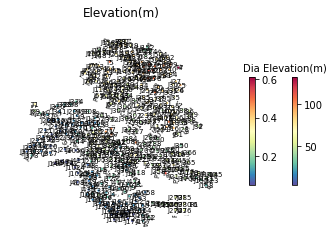

In [147]:
#ax = wntr.graphics.plot_network(wn, node_attribute='elevation',node_colorbar_label='Elevation(m)')
A=wn.node_name_list
print(A)
B=wn.link_name_list
print(B)
ax = wntr.graphics.network.plot_network(wn, node_attribute='elevation', link_attribute='diameter', title='Elevation(m)', node_size=5, node_range=[None, None], node_alpha=1, node_cmap=None, node_labels=True, link_width=1, link_range=[None, None], link_alpha=1, link_cmap=None, link_labels=True, add_colorbar=True, node_colorbar_label='Elevation(m)', link_colorbar_label='Dia', directed=False, ax=None, filename=None)

In [148]:
A2 = ['P1', 'P10', 'P100', 'P1000', 'P101', 'P1016', 'P102', 'P1022', 'P1023', 'P1024', 'P1025', 'P1026', 'P1027', 'P1028', 'P1029', 'P103', 'P1030', 'P1031', 'P1032', 'P1033', 'P1034', 'P1035', 'P1036', 'P1039', 'P104', 'P1040', 'P1041', 'P1042', 'P1044', 'P1045', 'P106', 'P107', 'P108', 'P109', 'P11', 'P110', 'P111', 'P112', 'P113', 'P115', 'P116', 'P117', 'P118', 'P119', 'P12', 'P120', 'P121', 'P122', 'P123', 'P124', 'P125', 'P126', 'P127', 'P128', 'P129', 'P13', 'P130', 'P131', 'P132', 'P134', 'P136', 'P138', 'P139', 'P14', 'P140', 'P141', 'P142', 'P144', 'P147', 'P148', 'P15', 'P150', 'P154', 'P155', 'P156', 'P157', 'P158', 'P159', 'P16', 'P160', 'P161', 'P162', 'P163', 'P165', 'P166', 'P17', 'P174', 'P177', 'P18', 'P184', 'P19', 'P195', 'P2', 'P20', 'P201', 'P21', 'P211', 'P215', 'P218', 'P219', 'P22', 'P220', 'P223', 'P225', 'P228', 'P23', 'P230', 'P231', 'P233', 'P234', 'P235', 'P237', 'P238', 'P24', 'P241', 'P242', 'P243', 'P245', 'P246', 'P248', 'P249', 'P25', 'P251', 'P252', 'P255', 'P256', 'P258', 'P259', 'P26', 'P264', 'P266', 'P267', 'P268', 'P27', 'P270', 'P272', 'P275', 'P28', 'P280', 'P282', 'P284', 'P285', 'P286', 'P287', 'P288', 'P29', 'P290', 'P291', 'P292', 'P293', 'P294', 'P295', 'P296', 'P297', 'P298', 'P299', 'P3', 'P30', 'P301', 'P302', 'P303', 'P304', 'P305', 'P307', 'P308', 'P309', 'P31', 'P310', 'P316', 'P319', 'P32', 'P320', 'P322', 'P323', 'P329', 'P33', 'P330', 'P331', 'P336', 'P337', 'P338', 'P339', 'P34', 'P340', 'P341', 'P343', 'P344', 'P346', 'P347', 'P348', 'P349', 'P35', 'P350', 'P37', 'P372', 'P374', 'P375', 'P376', 'P378', 'P379', 'P38', 'P380', 'P381', 'P383', 'P384', 'P385', 'P386', 'P39', 'P397', 'P398', 'P399', 'P40', 'P402', 'P403', 'P409', 'P410', 'P42', 'P424', 'P43', 'P44', 'P443', 'P445', 'P446', 'P450', 'P46', 'P465', 'P467', 'P468', 'P48', 'P482', 'P484', 'P49', 'P492', 'P5', 'P500', 'P501', 'P502', 'P51', 'P510', 'P52', 'P524', 'P527', 'P529', 'P53', 'P54', 'P55', 'P57', 'P58', 'P596', 'P597', 'P6', 'P609', 'P610', 'P63', 'P633', 'P64', 'P65', 'P67', 'P670', 'P671', 'P68', 'P69', 'P697', 'P7', 'P70', 'P71', 'P72', 'P724', 'P725', 'P752', 'P753', 'P754', 'P755', 'P756', 'P757', 'P758', 'P759', 'P760', 'P761', 'P763', 'P766', 'P767', 'P768', 'P769', 'P771', 'P772', 'P775', 'P776', 'P777', 'P779', 'P780', 'P781', 'P783', 'P784', 'P785', 'P786', 'P787', 'P788', 'P789', 'P791', 'P794', 'P795', 'P796', 'P797', 'P798', 'P8', 'P800', 'P801', 'P804', 'P805', 'P806', 'P807', 'P808', 'P809', 'P810', 'P811', 'P813', 'P815', 'P817', 'P819', 'P821', 'P822', 'P823', 'P826', 'P827', 'P83', 'P830', 'P831', 'P84', 'P840', 'P841', 'P842', 'P844', 'P846', 'P847', 'P85', 'P850', 'P851', 'P852', 'P853', 'P855', 'P858', 'P859', 'P86', 'P861', 'P866', 'P87', 'P871', 'P880', 'P889', 'P89', 'P892', 'P9', 'P90', 'P91', 'P914', 'P915', 'P92', 'P924', 'P927', 'P929', 'P930', 'P931', 'P932', 'P933', 'P934', 'P935', 'P937', 'P938', 'P939', 'P94', 'P940', 'P941', 'P942', 'P943', 'P944', 'P946', 'P947', 'P948', 'P949', 'P95', 'P951', 'P953', 'P954', 'P955', 'P956', 'P957', 'P958', 'P959', 'P96', 'P961', 'P962', 'P963', 'P964', 'P965', 'P966', 'P967', 'P968', 'P969', 'P97', 'P970', 'P971', 'P972', 'P973', 'P974', 'P975', 'P976', 'P977', 'P978', 'P98', 'P981', 'P982', 'P983', 'P984', 'P986', 'P987', 'P988', 'P989', 'P99', 'P990', 'P991', 'P992', 'P993', 'P994', 'P995', 'P996', 'P997', 'P998', 'P999']

In [149]:
coeff = [[],[]]
for i in range(len(A2)):
    junction = wn.get_link(A2[i])
    #junction.demand_timeseries_list[0].pattern_name=A[i+9]
    pat_i = junction.roughness
    coeff[0].append(A2[i])
    coeff[1].append(pat_i)
    print(f'{A2[i]} have coeff {pat_i}')

P1 have coeff 72.4549266
P10 have coeff 108.0095074
P100 have coeff 76.51422883
P1000 have coeff 76.94614787
P101 have coeff 84.20845169
P1016 have coeff 85.23817366
P102 have coeff 92.94722922
P1022 have coeff 99.58078005
P1023 have coeff 95.68850653
P1024 have coeff 89.62069894
P1025 have coeff 97.77659267
P1026 have coeff 88.45039526
P1027 have coeff 92.0106009
P1028 have coeff 86.99339612
P1029 have coeff 91.33959845
P103 have coeff 79.37099717
P1030 have coeff 104.6083303
P1031 have coeff 84.37414232
P1032 have coeff 98.43095137
P1033 have coeff 84.68939593
P1034 have coeff 97.41854735
P1035 have coeff 97.7581413
P1036 have coeff 74.29791874
P1039 have coeff 92.14229573
P104 have coeff 99.88658284
P1040 have coeff 94.68876721
P1041 have coeff 112.5081558
P1042 have coeff 76.15024112
P1044 have coeff 100.2182444
P1045 have coeff 118.82139
P106 have coeff 63.55113264
P107 have coeff 80.50983232
P108 have coeff 78.72048108
P109 have coeff 76.89340854
P11 have coeff 96.83442437
P110 h

In [150]:
coeff

[['P1',
  'P10',
  'P100',
  'P1000',
  'P101',
  'P1016',
  'P102',
  'P1022',
  'P1023',
  'P1024',
  'P1025',
  'P1026',
  'P1027',
  'P1028',
  'P1029',
  'P103',
  'P1030',
  'P1031',
  'P1032',
  'P1033',
  'P1034',
  'P1035',
  'P1036',
  'P1039',
  'P104',
  'P1040',
  'P1041',
  'P1042',
  'P1044',
  'P1045',
  'P106',
  'P107',
  'P108',
  'P109',
  'P11',
  'P110',
  'P111',
  'P112',
  'P113',
  'P115',
  'P116',
  'P117',
  'P118',
  'P119',
  'P12',
  'P120',
  'P121',
  'P122',
  'P123',
  'P124',
  'P125',
  'P126',
  'P127',
  'P128',
  'P129',
  'P13',
  'P130',
  'P131',
  'P132',
  'P134',
  'P136',
  'P138',
  'P139',
  'P14',
  'P140',
  'P141',
  'P142',
  'P144',
  'P147',
  'P148',
  'P15',
  'P150',
  'P154',
  'P155',
  'P156',
  'P157',
  'P158',
  'P159',
  'P16',
  'P160',
  'P161',
  'P162',
  'P163',
  'P165',
  'P166',
  'P17',
  'P174',
  'P177',
  'P18',
  'P184',
  'P19',
  'P195',
  'P2',
  'P20',
  'P201',
  'P21',
  'P211',
  'P215',
  'P218',
  '

In [151]:
len(coeff[0])

429

In [152]:
A1 = ['J511', 'J411', 'J414', 'J415', 'J416', 'J417', 'J418', 'J419', 'J310', 'J311', 'J312', 'J313', 'J314', 'J315', 'J316', 'J318', 'J319', 'J210', 'J211', 'J212', 'J214', 'J217', 'J218', 'J219', 'J110', 'J420', 'J421', 'J422', 'J1153', 'J1154', 'J1155', 'J425', 'J426', 'J1157', 'J427', 'J1158', 'J428', 'J429', 'J320', 'J321', 'J322', 'J324', 'J1056', 'J327', 'J1058', 'J328', 'J329', 'J220', 'J221', 'J225', 'J226', 'J50', 'J51', 'J53', 'J54', 'J128', 'J55', 'J129', 'J56', 'J57', 'J58', 'J59', 'J1160', 'J1161', 'J431', 'J432', 'J433', 'J434', 'J435', 'J436', 'J438', 'J1169', 'J439', 'J330', 'J331', 'J332', 'J333', 'J334', 'J335', 'J336', 'J337', 'J231', 'J232', 'J233', 'J234', 'J236', 'J237', 'J130', 'J131', 'J132', 'J133', 'J60', 'J134', 'J135', 'J62', 'J64', 'J65', 'J66', 'J67', 'J68', 'J69', 'J1170', 'J441', 'J444', 'J341', 'J344', 'J345', 'J347', 'J348', 'J349', 'J241', 'J242', 'J243', 'J244', 'J245', 'J246', 'J247', 'J248', 'J249', 'J142', 'J143', 'J70', 'J144', 'J71', 'J72', 'J73', 'J74', 'J76', 'J77', 'J78', 'J350', 'J351', 'J352', 'J353', 'J354', 'J355', 'J358', 'J359', 'J250', 'J251', 'J252', 'J253', 'J254', 'J257', 'J154', 'J155', 'J82', 'J156', 'J83', 'J84', 'J85', 'J159', 'J86', 'J87', 'J89', 'J360', 'J361', 'J362', 'J363', 'J364', 'J365', 'J366', 'J1208', 'J367', 'J369', 'J160', 'J161', 'J162', 'J163', 'J164', 'J91', 'J165', 'J166', 'J167', 'J94', 'J95', 'J96', 'J97', 'J976', 'J571', 'J572', 'J573', 'J574', 'J575', 'J576', 'J370', 'J371', 'J372', 'J373', 'J374', 'J375', 'J376', 'J377', 'J1219', 'J379', 'J171', 'J172', 'J173', 'J174', 'J175', 'J177', 'J179', 'J580', 'J486', 'J487', 'J488', 'J489', 'J381', 'J1223', 'J382', 'J384', 'J385', 'J180', 'J181', 'J1024', 'J183', 'J1025', 'J186', 'J187', 'J188', 'J189', 'J490', 'J491', 'J492', 'J493', 'J494', 'J495', 'J496', 'J497', 'J498', 'J500', 'J499', 'J501', 'J502', 'J503', 'J504', 'J394', 'J509', 'J399', 'J401', 'J406', 'J295', 'J407', 'J296', 'J408', 'J297', 'J298', 'J191', 'J303', 'J192', 'J193', 'J305', 'J194', 'J195', 'J196', 'J308', 'J198', 'J200', 'J199', 'J201', 'J202', 'J203', 'J204', 'J205', 'J206', 'J207', 'J208', 'J101', 'J102', 'J109', 'J1', 'J2', 'J3', 'J4', 'J5', 'J6', 'J7', 'J8', 'J9', 'J10', 'J11', 'J12', 'J13', 'J14', 'J15', 'J16', 'J17', 'J18', 'J19', 'J20', 'J21', 'J22', 'J23', 'J25', 'J26', 'J27', 'J28', 'J29', 'J30', 'J31', 'J32', 'J33', 'J34', 'J35', 'J36', 'J37', 'J38', 'J24', 'J39', 'J40', 'J123', 'J140', 'J141', 'J157', 'J158', 'J168', 'J170', 'J176', 'J178', 'J184', 'J185', 'J190', 'J197', 'J213', 'J215', 'J216', 'J227', 'J238', 'J239', 'J255', 'J256', 'J258', 'J260', 'J265', 'J266', 'J267', 'J61', 'J92', 'J268', 'J278', 'J281', 'J283', 'J284', 'J136', 'J137', 'J145', 'J118', 'J52', 'J81', 'J88', 'J90', 'J93', 'J147', 'J148', 'J149', 'J150', 'J151', 'J152', 'J153', 'J169', 'J182', 'J222', 'J224', 'J230', 'J235', 'J240', 'J269', 'J273', 'J274', 'J276', 'J280', 'J285', 'J287', 'J288', 'J289', 'J290', 'J291', 'J292', 'J299', 'J300', 'J301', 'J302', 'J304', 'J306', 'J307', 'J309', 'J317', 'J323']

In [153]:
pat = [[],[]]
for i in range(len(A1)):
    junction = wn.get_node(A1[i])
    #junction.demand_timeseries_list[0].pattern_name=A[i+9]
    pat_i = junction.demand_timeseries_list[0].pattern_name
    pat[0].append(A1[i])
    pat[1].append(pat_i)
    print(f'{A1[i]} have pattern {pat_i}')
    
    #+ junction.demand_timeseries_list[0]

J511 have pattern DMA2_pat
J411 have pattern DMA1_pat
J414 have pattern DMA1_pat
J415 have pattern 
J416 have pattern 
J417 have pattern DMA1_pat
J418 have pattern 
J419 have pattern 
J310 have pattern DMA4_pat
J311 have pattern DMA4_pat
J312 have pattern DMA4_pat
J313 have pattern DMA4_pat
J314 have pattern DMA1_pat
J315 have pattern DMA1_pat
J316 have pattern DMA1_pat
J318 have pattern DMA4_pat
J319 have pattern DMA4_pat
J210 have pattern DMA1_pat
J211 have pattern DMA1_pat
J212 have pattern DMA1_pat
J214 have pattern DMA1_pat
J217 have pattern DMA1_pat
J218 have pattern DMA1_pat
J219 have pattern DMA5_pat
J110 have pattern DMA1_pat
J420 have pattern 
J421 have pattern DMA1_pat
J422 have pattern 
J1153 have pattern DMA1_pat
J1154 have pattern DMA1_pat
J1155 have pattern DMA1_pat
J425 have pattern 
J426 have pattern 
J1157 have pattern DMA1_pat
J427 have pattern 
J1158 have pattern DMA1_pat
J428 have pattern DMA1_pat
J429 have pattern DMA1_pat
J320 have pattern DMA4_pat
J321 have patt

In [154]:
pat = np.transpose(pat)

In [155]:
pat = pd.DataFrame(pat)
pat

,0,1
0,J511,DMA2_pat
1,J411,DMA1_pat
2,J414,DMA1_pat
3,J415,
4,J416,
...,...,...
383,J306,
384,J307,
385,J309,
386,J317,


In [156]:
pat_1 = pat.loc[pat[1] != '']
pat_1

#df = df.loc[df['salary'] * df['age'] != 0]

,0,1
0,J511,DMA2_pat
1,J411,DMA1_pat
2,J414,DMA1_pat
5,J417,DMA1_pat
8,J310,DMA4_pat
...,...,...
361,J222,DMA2_pat
362,J224,DMA2_pat
363,J230,DMA4_pat
364,J235,DMA4_pat


In [157]:
wn.pattern_name_list

['DMA1_pat', 'DMA2_pat', 'DMA3_pat', 'DMA4_pat', 'DMA5_pat']

In [158]:
DMA1_pat = [0.569, 0.465, 0.439, 0.36 , 0.31 , 0.335, 0.385, 0.472, 0.55 , 0.681, 0.704, 0.671, 0.797, 0.72 , 0.771, 0.738, 0.815, 0.724, 0.807, 0.779, 0.867, 0.741, 0.67 , 0.632, 0.523, 0.507, 0.446, 0.455, 0.475, 0.534, 0.663, 0.622, 0.676, 0.726, 0.803, 0.701, 0.693, 0.654, 0.621, 0.652, 0.572,
       0.579, 0.582, 0.712, 0.705, 0.666, 0.742, 0.692, 0.727, 0.619, 0.463, 0.451, 0.309, 0.282, 0.433, 0.407, 0.545, 0.699, 0.74 , 0.643, 0.681, 0.691, 0.677, 0.626, 0.627, 0.714, 0.682, 0.788, 0.758, 0.788, 0.802, 0.846, 0.605, 0.444, 0.513, 0.365, 0.318, 0.464, 0.396, 0.641, 0.671, 0.669,
       0.795, 0.675, 0.754, 0.808, 0.714, 0.686, 0.681, 0.55 , 0.682, 0.57 , 0.743, 0.832, 0.679, 0.746, 0.601, 0.504, 0.519, 0.359, 0.299, 0.453, 0.43 , 0.539, 0.896, 0.897, 0.683, 0.58 , 0.429, 0.42 , 0.629, 0.691, 0.671, 0.619, 0.683, 0.833, 0.903, 0.822, 0.849, 0.691, 0.716, 0.548, 0.533,
       0.42 , 0.356, 0.338, 0.452, 0.51 , 0.565, 0.761, 0.622, 0.678, 0.693, 0.639, 0.62 , 0.66 , 0.656, 0.632, 0.604, 0.704, 0.772, 0.885, 0.883, 0.752, 0.714, 0.458, 0.447, 0.429, 0.402, 0.433, 0.47 , 0.522, 0.591, 0.755, 0.77 , 0.645, 0.732, 0.71 , 0.548, 0.578, 0.592, 0.624, 0.56 , 0.767,
       0.717, 0.775, 0.904, 0.857]

In [159]:
DMA2_pat =  [0.618, 0.454, 0.445, 0.338, 0.316, 0.313, 0.414, 0.449, 0.499, 0.582, 0.684, 0.728, 0.67 , 0.792, 0.668, 0.816, 0.771, 0.83 , 0.808, 0.793, 0.836, 0.837, 0.678, 0.662, 0.568, 0.471, 0.471, 0.426, 0.428, 0.474, 0.579, 0.623, 0.684, 0.774, 0.771, 0.796, 0.663, 0.736, 0.712, 0.595, 0.635,
       0.617, 0.582, 0.597, 0.701, 0.651, 0.716, 0.732, 0.681, 0.734, 0.499, 0.374, 0.316, 0.276, 0.348, 0.461, 0.529, 0.626, 0.669, 0.765, 0.666, 0.651, 0.757, 0.561, 0.655, 0.645, 0.716, 0.84 , 0.771, 0.79 , 0.848, 0.821, 0.665, 0.502, 0.493, 0.416, 0.361, 0.438, 0.394, 0.654, 0.606, 0.811,
       0.769, 0.643, 0.697, 0.676, 0.708, 0.708, 0.706, 0.539, 0.581, 0.565, 0.754, 0.825, 0.694, 0.794, 0.752, 0.508, 0.485, 0.38 , 0.337, 0.394, 0.484, 0.642, 0.813, 0.846, 0.683, 0.593, 0.426, 0.42 , 0.583, 0.624, 0.587, 0.563, 0.66 , 0.812, 0.812, 0.882, 0.858, 0.857, 0.67 , 0.574, 0.502,
       0.432, 0.374, 0.354, 0.467, 0.466, 0.593, 0.717, 0.586, 0.586, 0.681, 0.648, 0.69 , 0.716, 0.708, 0.682, 0.661, 0.734, 0.806, 0.796, 0.842, 0.712, 0.594, 0.465, 0.494, 0.445, 0.327, 0.513, 0.514, 0.526, 0.583, 0.601, 0.779, 0.663, 0.683, 0.729, 0.59 , 0.604, 0.588, 0.659, 0.626, 0.698,
       0.783, 0.818, 0.929, 0.79 ]

In [160]:
DMA3_pat = [0.544, 0.481, 0.422, 0.355, 0.324, 0.359, 0.41 , 0.473, 0.56 , 0.675, 0.754, 0.73 , 0.671, 0.734, 0.706, 0.761, 0.714, 0.836, 0.872, 0.738, 0.726, 0.75 , 0.671, 0.734, 0.587, 0.426, 0.443, 0.413, 0.433, 0.492, 0.554, 0.679, 0.754, 0.744, 0.794, 0.682, 0.695, 0.646, 0.594, 0.597, 0.639,
       0.646, 0.643, 0.682, 0.728, 0.679, 0.692, 0.758, 0.714, 0.702, 0.504, 0.395, 0.315, 0.286, 0.42 , 0.432, 0.496, 0.698, 0.589, 0.694, 0.694, 0.767, 0.694, 0.581, 0.706, 0.702, 0.666, 0.823, 0.738, 0.859, 0.815, 0.71 , 0.606, 0.485, 0.455, 0.392, 0.368, 0.412, 0.408, 0.663, 0.603, 0.703,
       0.66 , 0.619, 0.71 , 0.81 , 0.763, 0.82 , 0.763, 0.599, 0.68 , 0.606, 0.69 , 0.814, 0.703, 0.666, 0.623, 0.575, 0.454, 0.368, 0.33 , 0.44 , 0.406, 0.619, 0.891, 0.946, 0.74 , 0.564, 0.458, 0.403, 0.671, 0.647, 0.592, 0.557, 0.623, 0.826, 0.891, 0.853, 0.753, 0.771, 0.746, 0.593, 0.488,
       0.38 , 0.335, 0.376, 0.447, 0.563, 0.526, 0.716, 0.637, 0.582, 0.675, 0.667, 0.637, 0.641, 0.671, 0.686, 0.6  , 0.731, 0.85 , 0.869, 0.842, 0.742, 0.664, 0.528, 0.513, 0.46 , 0.359, 0.478, 0.528, 0.564, 0.61 , 0.635, 0.801, 0.718, 0.614, 0.607, 0.621, 0.614, 0.718, 0.574, 0.582, 0.668,
       0.679, 0.916, 0.826, 0.725]

In [161]:
DMA4_pat = [0.525, 0.449, 0.437, 0.318, 0.318, 0.328, 0.425, 0.432, 0.574, 0.665, 0.691, 0.741, 0.762, 0.764, 0.719, 0.686, 0.828, 0.828, 0.745, 0.809, 0.831, 0.703, 0.774, 0.65 , 0.497, 0.45 , 0.439, 0.435, 0.427, 0.533, 0.634, 0.709, 0.764, 0.717, 0.762, 0.795, 0.769, 0.627, 0.599, 0.583, 0.601,
       0.593, 0.568, 0.593, 0.629, 0.771, 0.699, 0.807, 0.731, 0.666, 0.534, 0.397, 0.325, 0.257, 0.423, 0.438, 0.549, 0.693, 0.613, 0.751, 0.772, 0.674, 0.695, 0.664, 0.58 , 0.686, 0.671, 0.832, 0.739, 0.878, 0.751, 0.681, 0.672, 0.488, 0.53 , 0.415, 0.346, 0.421, 0.468, 0.579, 0.66 , 0.711,
       0.721, 0.619, 0.719, 0.713, 0.763, 0.709, 0.666, 0.526, 0.63 , 0.634, 0.717, 0.765, 0.761, 0.769, 0.717, 0.584, 0.5  , 0.397, 0.312, 0.452, 0.438, 0.607, 0.824, 0.83 , 0.746, 0.646, 0.419, 0.465, 0.591, 0.636, 0.593, 0.661, 0.704, 0.743, 0.752, 0.812, 0.876, 0.696, 0.66 , 0.585, 0.499,
       0.432, 0.342, 0.348, 0.469, 0.52 , 0.531, 0.641, 0.645, 0.581, 0.688, 0.731, 0.733, 0.662, 0.66 , 0.643, 0.621, 0.753, 0.787, 0.806, 0.841, 0.821, 0.593, 0.474, 0.461, 0.455, 0.374, 0.447, 0.457, 0.476, 0.651, 0.739, 0.726, 0.708, 0.662, 0.645, 0.639, 0.618, 0.662, 0.643, 0.632, 0.714,
       0.779, 0.743, 0.931, 0.772]

In [162]:
DMA5_pat = [0.536, 0.441, 0.407, 0.286, 0.323, 0.331, 0.368, 0.505, 0.589, 0.623, 0.725, 0.738, 0.77 , 0.694, 0.694, 0.759, 0.815, 0.807, 0.851, 0.815, 0.767, 0.715, 0.799, 0.641, 0.555, 0.496, 0.454, 0.436, 0.498, 0.531, 0.611, 0.602, 0.745, 0.745, 0.69 , 0.681, 0.655, 0.681, 0.628, 0.595, 0.639,
       0.615, 0.657, 0.589, 0.615, 0.741, 0.827, 0.714, 0.767, 0.705, 0.486, 0.367, 0.308, 0.308, 0.408, 0.448, 0.505, 0.683, 0.664, 0.74 , 0.694, 0.643, 0.772, 0.554, 0.589, 0.759, 0.653, 0.826, 0.818, 0.815, 0.813, 0.675, 0.655, 0.458, 0.52 , 0.354, 0.343, 0.438, 0.458, 0.626, 0.669, 0.75 ,
       0.719, 0.697, 0.768, 0.804, 0.633, 0.664, 0.728, 0.593, 0.673, 0.666, 0.607, 0.799, 0.722, 0.653, 0.637, 0.557, 0.559, 0.417, 0.306, 0.429, 0.417, 0.597, 0.779, 0.831, 0.744, 0.677, 0.457, 0.414, 0.55 , 0.576, 0.618, 0.604, 0.668, 0.82 , 0.782, 0.902, 0.879, 0.782, 0.703, 0.571, 0.454,
       0.426, 0.368, 0.353, 0.444, 0.502, 0.599, 0.733, 0.69 , 0.583, 0.766, 0.614, 0.644, 0.649, 0.644, 0.624, 0.594, 0.761, 0.763, 0.88 , 0.842, 0.794, 0.597, 0.483, 0.449, 0.432, 0.357, 0.447, 0.5  , 0.576, 0.668, 0.753, 0.755, 0.629, 0.721, 0.663, 0.542, 0.559, 0.583, 0.67 , 0.673, 0.668,
       0.755, 0.884, 0.847, 0.789]

In [163]:
Patt_1 = pd.DataFrame((DMA1_pat,DMA2_pat,DMA3_pat,DMA4_pat,DMA5_pat))

In [164]:
Patt_1

,0,1,2,3,4,5,6,7,8,9,...,158,159,160,161,162,163,164,165,166,167
0,0.569,0.465,0.439,0.360,0.310,0.335,0.385,0.472,0.550,0.681,...,0.548,0.578,0.592,0.624,0.560,0.767,0.717,0.775,0.904,0.857
1,0.618,0.454,0.445,0.338,0.316,0.313,0.414,0.449,0.499,0.582,...,0.590,0.604,0.588,0.659,0.626,0.698,0.783,0.818,0.929,0.790
2,0.544,0.481,0.422,0.355,0.324,0.359,0.410,0.473,0.560,0.675,...,0.621,0.614,0.718,0.574,0.582,0.668,0.679,0.916,0.826,0.725
3,0.525,0.449,0.437,0.318,0.318,0.328,0.425,0.432,0.574,0.665,...,0.639,0.618,0.662,0.643,0.632,0.714,0.779,0.743,0.931,0.772
4,0.536,0.441,0.407,0.286,0.323,0.331,0.368,0.505,0.589,0.623,...,0.542,0.559,0.583,0.670,0.673,0.668,0.755,0.884,0.847,0.789


In [165]:
#C_mat = np.array(coeff[1]+np.random.randint(-2, 2,np.shape(coeff)[1]))

In [166]:
#D_p = pd.read_csv("patt_quality_gt1.csv")
P_m = pd.read_csv("P_moni.csv")
Q_m = pd.read_csv("Q_quality_gt1.csv") 
F_m = pd.read_csv("F_quality_gt1.csv")
pat_n  = pd.read_csv("Pat_name.csv")
C_n  = pd.read_csv("C.csv")
dos_p = pd.read_csv("dossing.csv")

In [167]:
K1= list(zip(np.array(coeff[1])-2,np.array(coeff[1])+2))
print(K1)

[(70.4549266, 74.4549266), (106.0095074, 110.0095074), (74.51422883, 78.51422883), (74.94614787, 78.94614787), (82.20845169, 86.20845169), (83.23817366, 87.23817366), (90.94722922, 94.94722922), (97.58078005, 101.58078005), (93.68850653, 97.68850653), (87.62069894, 91.62069894), (95.77659267, 99.77659267), (86.45039526, 90.45039526), (90.0106009, 94.0106009), (84.99339612, 88.99339612), (89.33959845, 93.33959845), (77.37099717, 81.37099717), (102.6083303, 106.6083303), (82.37414232, 86.37414232), (96.43095137, 100.43095137), (82.68939593, 86.68939593), (95.41854735, 99.41854735), (95.7581413, 99.7581413), (72.29791874, 76.29791874), (90.14229573, 94.14229573), (97.88658284, 101.88658284), (92.68876721, 96.68876721), (110.5081558, 114.5081558), (74.15024112, 78.15024112), (98.2182444, 102.2182444), (116.82139, 120.82139), (61.55113264, 65.55113263999999), (78.50983232, 82.50983232), (76.72048108, 80.72048108), (74.89340854, 78.89340854), (94.83442437, 98.83442437), (96.99414116, 100.994

In [168]:
sensor_no = [22, 26, 28, 38, 55, 58, 65, 70, 75, 79, 92, 102, 109, 114, 119, 128, 147, 148, 153, 164, 190, 195, 205, 206, 210, 211, 244, 252, 286, 303, 306, 313, 317, 327, 332, 339, 359, 372, 389, 390, 391, 392, 393, 394, 395]

In [169]:
len(sensor_no)

45

In [170]:
P_m

,Unnamed: 0,J511,J411,J414,J415,J416,J417,J418,J419,J310,...,J317,J323,R1,T3,T1,T7,T6,T5,T2,T4
0,0,29.964436,65.432150,34.589380,84.596825,99.193100,29.787249,28.905605,25.282110,53.830740,...,68.696470,68.696470,-0.000001,2.999995,3.000001,2.500003,5.199999,1.000002,0.500002,2.500002
1,3600,30.380690,65.560930,34.830494,86.614150,101.489210,30.047169,29.171589,25.540472,54.741570,...,69.879950,69.879950,-0.000001,3.513583,2.818585,2.996373,5.462755,1.561856,0.728490,2.758470
2,7200,30.988132,65.568750,34.980380,87.223915,102.159134,30.239788,29.384575,25.767760,56.881570,...,74.749000,74.749000,-0.000001,4.049187,2.695327,3.960425,5.499999,2.215184,0.969183,3.355745
3,10800,31.749052,65.844350,35.286217,89.125550,104.314060,30.542301,29.683040,26.048060,53.658760,...,61.304745,61.304745,-0.000001,4.603888,2.617322,4.584982,5.453211,2.904955,1.202833,3.966145
4,14400,31.379066,66.449190,36.974483,69.635950,92.035950,32.591244,31.909458,27.865353,52.881200,...,60.583180,60.583180,-0.000001,5.188699,2.697150,3.710366,5.249065,3.754550,1.585094,4.230501
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
164,590400,29.795980,62.867275,35.827827,60.089920,82.489920,32.306244,32.058315,28.343662,53.068584,...,66.625404,66.625404,-0.000001,3.527805,1.781555,2.679638,5.383122,3.852544,2.415694,3.833195
165,594000,30.371119,62.903297,34.972607,84.093346,98.251300,31.165052,30.778519,27.434546,53.134830,...,67.601060,67.601060,-0.000001,3.139959,1.465337,2.532671,5.493916,3.597239,2.775486,2.963294
166,597600,30.146519,62.162895,34.248980,83.247696,97.431380,30.458580,30.083147,26.896105,52.847210,...,66.641136,66.641136,-0.000001,3.281178,1.166825,2.684075,5.499999,2.629261,2.676944,2.812224
167,601200,29.832054,64.021770,35.053173,83.633170,97.843910,30.912176,30.364240,27.005651,52.990532,...,68.632360,68.632360,-0.000001,3.691702,0.972288,2.222392,5.499999,1.701169,2.527734,2.415086


In [171]:
P_m1 = pd.DataFrame(np.array(P_m.iloc[29:54,1:]))
P_m1

,0,1,2,3,4,5,6,7,8,9,...,386,387,388,389,390,391,392,393,394,395
0,30.691006,65.349400,36.580260,87.553120,102.076110,32.468580,31.927034,28.375898,54.898490,50.805660,...,70.186630,70.186630,-0.000001,4.825382,1.699378,3.464316,5.387718,2.324209,3.331490,3.069985
1,31.168205,65.237660,36.630833,86.818405,101.201490,32.587967,32.083454,28.588648,55.745323,51.659070,...,72.646660,72.646660,-0.000001,4.544199,1.813623,4.192523,5.499999,1.742450,3.655758,3.662331
2,31.503422,65.098785,36.695663,86.702550,101.041510,32.715940,32.241547,28.787416,55.378304,51.297462,...,70.284775,70.284775,-0.000001,4.227418,1.788168,4.612915,5.499999,1.804037,3.931067,4.031619
3,31.745472,65.002650,36.756120,86.405750,100.674706,32.833820,32.388885,28.974024,55.286335,51.209812,...,69.609600,69.609600,-0.000001,3.839405,1.730246,4.738955,5.499999,2.285905,4.190581,4.307836
4,31.874105,64.902460,36.803722,85.891670,100.060850,32.935104,32.517616,29.138344,55.395397,51.315155,...,70.159460,70.159460,-0.000001,3.408296,1.658283,4.678456,5.499999,2.618052,4.419926,4.454375
5,31.825560,64.631450,36.463480,85.711105,99.958560,32.579613,32.156345,28.914860,55.314790,51.238110,...,69.599200,69.599200,-0.000001,3.018673,1.576572,4.770627,5.499999,2.945353,4.604375,4.406630
6,31.771387,64.697820,36.431330,85.501530,99.732086,32.505013,32.058678,28.786617,55.147533,51.073597,...,69.153410,69.153410,-0.000001,3.462749,1.460021,4.709245,5.499999,3.321163,4.419837,4.357655
7,31.699306,64.628750,36.326862,86.335655,100.712310,32.388040,31.935377,28.653570,55.070860,50.994820,...,69.342316,69.342316,-0.000001,3.947379,1.381217,4.542771,5.499999,3.702646,4.267279,4.255066
8,31.858460,64.871400,36.375942,85.889950,100.208390,32.368996,31.881935,28.567213,56.068848,51.982056,...,72.920310,72.920310,-0.000001,4.420541,1.343400,4.499908,5.499999,3.811858,4.133259,4.437018
9,31.886114,65.489960,36.599700,86.085270,100.434135,32.458115,31.904007,28.537958,50.642193,46.553560,...,57.816826,57.816826,-0.000001,4.908521,1.478457,4.054531,5.340716,3.065950,4.048227,4.459584


In [172]:
# zero_flow = ['PU3','PU5','PU6','PU9','PU11','P446']
# F_m11 = F_m1.copy()
# F_m11.drop(zero_flow,inplace=True) #F_m1.drop(zero_flow, axis=1,inplace=True)
# F_m11

In [173]:
# P_m = P_m.filter(sensor_no, axis=1)
# P_m

In [174]:
K_pm = P_m1.filter(sensor_no)
K_pm

,22,26,28,38,55,58,65,70,75,79,...,339,359,372,389,390,391,392,393,394,395
0,65.726750,32.596830,51.080940,60.503445,52.104713,35.046406,52.202324,63.733902,26.903060,48.504738,...,30.733488,40.0,28.882935,4.825382,1.699378,3.464316,5.387718,2.324209,3.331490,3.069985
1,65.726770,32.727100,50.979300,61.457962,50.660755,34.147670,51.206066,63.626270,26.879230,48.459820,...,30.786722,40.0,29.054092,4.544199,1.813623,4.192523,5.499999,1.742450,3.655758,3.662331
2,65.565620,32.864307,50.021580,60.941875,50.226845,36.724640,51.423378,63.496075,20.691082,45.716297,...,30.931364,40.0,29.225504,4.227418,1.788168,4.612915,5.499999,1.804037,3.931067,4.031619
3,65.484260,32.990986,49.877045,60.803883,49.442970,36.746544,50.935127,63.405250,20.454994,45.542510,...,30.894157,40.0,29.385412,3.839405,1.730246,4.738955,5.499999,2.285905,4.190581,4.307836
4,65.393780,33.100480,49.748466,60.948227,48.129040,37.064793,50.437065,63.310150,20.374120,45.431230,...,30.576801,40.0,29.525063,3.408296,1.658283,4.678456,5.499999,2.618052,4.419926,4.454375
5,65.223410,32.743050,49.484325,60.829853,48.103840,37.523900,49.439716,63.035220,20.148956,45.199245,...,30.544365,40.0,28.831566,3.018673,1.576572,4.770627,5.499999,2.945353,4.604375,4.406630
6,65.200760,32.661690,49.580580,60.640450,47.678722,37.915160,50.415234,63.099236,20.261904,45.284863,...,30.364172,40.0,28.732530,3.462749,1.460021,4.709245,5.499999,3.321163,4.419837,4.357655
7,65.128440,32.542820,49.524930,60.584286,49.705082,38.359833,50.408780,63.028896,20.264202,45.248352,...,30.946163,40.0,28.612858,3.947379,1.381217,4.542771,5.499999,3.702646,4.267279,4.255066
8,65.295330,32.513440,50.578740,61.778910,48.665210,35.904076,50.934690,63.264538,26.487925,48.048530,...,30.753273,40.0,28.546667,4.420541,1.343400,4.499908,5.499999,3.811858,4.133259,4.437018
9,65.938420,32.582325,51.623074,55.688206,49.079690,35.395650,51.713905,63.868153,29.439526,49.784504,...,30.900930,40.0,28.543737,4.908521,1.478457,4.054531,5.340716,3.065950,4.048227,4.459584


In [175]:
F_m

,Unnamed: 0,J511,J411,J414,J415,J416,J417,J418,J419,J310,...,J317,J323,R1,T3,T1,T7,T6,T5,T2,T4
0,0,0.000727,0.000506,0.000550,0.0,0.0,0.000735,0.0,0.0,0.000712,...,0.0,0.0,-0.193200,0.021126,-0.038838,0.005525,0.003977,0.017334,0.021568,0.007642
1,3600,0.000534,0.000413,0.000449,0.0,0.0,0.000600,0.0,0.0,0.000609,...,0.0,0.0,-0.192304,0.022040,-0.027411,0.007634,0.004673,0.020094,0.022755,0.017678
2,7200,0.000523,0.000390,0.000424,0.0,0.0,0.000566,0.0,0.0,0.000593,...,0.0,0.0,-0.192135,0.022849,-0.021799,0.011372,0.000000,0.021021,0.022221,0.018086
3,10800,0.000398,0.000320,0.000348,0.0,0.0,0.000465,0.0,0.0,0.000432,...,0.0,0.0,-0.191045,0.023787,0.013082,-0.009828,-0.002990,0.026241,0.024034,0.024341
4,14400,0.000371,0.000275,0.000299,0.0,0.0,0.000400,0.0,0.0,0.000432,...,0.0,0.0,-0.189343,0.025024,0.029103,-0.009404,-0.003414,0.025000,0.058272,-0.021157
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
164,590400,0.000920,0.000637,0.000693,0.0,0.0,0.000926,0.0,0.0,0.001057,...,0.0,0.0,-0.119568,-0.015951,-0.074485,-0.002166,0.001385,0.008881,0.051731,-0.052430
165,594000,0.000961,0.000689,0.000748,0.0,0.0,0.001000,0.0,0.0,0.001009,...,0.0,0.0,-0.119641,-0.021520,-0.062393,-0.000046,0.002264,-0.029855,0.015816,-0.004257
166,597600,0.001093,0.000804,0.000874,0.0,0.0,0.001168,0.0,0.0,0.001264,...,0.0,0.0,-0.120998,0.016880,-0.073983,-0.005312,0.000000,-0.028625,-0.021498,-0.011820
167,601200,0.000929,0.000762,0.000828,0.0,0.0,0.001107,0.0,0.0,0.001048,...,0.0,0.0,-0.198072,0.018505,-0.006896,0.000910,0.000000,-0.026657,-0.005448,-0.002562


In [176]:
F_m1 = pd.DataFrame(np.array(F_m.iloc[29:54,1:]))
F_m1

,0,1,2,3,4,5,6,7,8,9,...,386,387,388,389,390,391,392,393,394,395
0,0.000557,0.000475,0.000516,0.0,0.0,0.000689,0.0,0.0,0.000723,0.000629,...,0.0,0.0,-0.193181,-0.011564,0.023613,0.005894,0.004597,-0.017943,0.030734,0.017536
1,0.000681,0.000589,0.000640,0.0,0.0,0.000855,0.0,0.0,0.000861,0.000750,...,0.0,0.0,-0.194174,-0.013029,0.014557,0.005674,0.000000,-0.020623,0.027156,0.010943
2,0.000733,0.000553,0.000601,0.0,0.0,0.000804,0.0,0.0,0.000962,0.000838,...,0.0,0.0,-0.194265,-0.015958,-0.012380,0.001402,0.000000,0.014862,0.024448,0.008165
3,0.000804,0.000601,0.000653,0.0,0.0,0.000873,0.0,0.0,0.001037,0.000902,...,0.0,0.0,-0.194792,-0.017730,-0.015381,-0.000673,0.000000,0.010244,0.021606,0.004331
4,0.000911,0.000645,0.000701,0.0,0.0,0.000937,0.0,0.0,0.000973,0.000847,...,0.0,0.0,-0.195306,-0.017499,-0.017411,0.001027,0.000000,0.010100,0.018770,-0.001402
5,0.000907,0.000714,0.000776,0.0,0.0,0.001037,0.0,0.0,0.001034,0.000900,...,0.0,0.0,-0.196364,0.018264,-0.024911,-0.000683,0.000000,0.011591,-0.017384,-0.001448
6,0.000936,0.000624,0.000678,0.0,0.0,0.000906,0.0,0.0,0.001079,0.000939,...,0.0,0.0,-0.195639,0.019932,-0.016843,-0.001852,0.000000,0.011766,-0.014372,-0.003033
7,0.000779,0.000616,0.000670,0.0,0.0,0.000895,0.0,0.0,0.001045,0.000909,...,0.0,0.0,-0.195752,0.019498,-0.016144,-0.000882,0.000000,0.012438,-0.013195,0.005399
8,0.000866,0.000581,0.000632,0.0,0.0,0.000844,0.0,0.0,0.000851,0.000740,...,0.0,0.0,-0.194969,0.020113,0.017962,0.005794,0.000000,-0.023006,-0.009840,0.000670
9,0.000837,0.000553,0.000600,0.0,0.0,0.000802,0.0,0.0,0.000813,0.000708,...,0.0,0.0,-0.193359,0.020787,0.045312,-0.018668,-0.005477,-0.021219,-0.003602,0.002210


In [177]:
K_fm = F_m1.filter(sensor_no)
K_fm

,22,26,28,38,55,58,65,70,75,79,...,339,359,372,389,390,391,392,393,394,395
0,0.000048,0.000554,0.000235,0.000217,0.000317,0.000144,0.000185,0.000806,0.000707,0.000087,...,0.000680,0.000324,0.0,-0.011564,0.023613,0.005894,0.004597,-0.017943,0.030734,0.017536
1,0.000059,0.000688,0.000291,0.000258,0.000388,0.000166,0.000229,0.001000,0.000877,0.000108,...,0.000831,0.000397,0.0,-0.013029,0.014557,0.005674,0.000000,-0.020623,0.027156,0.010943
2,0.000056,0.000646,0.000274,0.000288,0.000417,0.000163,0.000215,0.000940,0.000824,0.000102,...,0.000894,0.000427,0.0,-0.015958,-0.012380,0.001402,0.000000,0.014862,0.024448,0.008165
3,0.000060,0.000702,0.000297,0.000311,0.000458,0.000202,0.000234,0.001021,0.000895,0.000110,...,0.000981,0.000468,0.0,-0.017730,-0.015381,-0.000673,0.000000,0.010244,0.021606,0.004331
4,0.000065,0.000753,0.000319,0.000291,0.000518,0.000202,0.000251,0.001096,0.000961,0.000119,...,0.001111,0.000530,0.0,-0.017499,-0.017411,0.001027,0.000000,0.010100,0.018770,-0.001402
5,0.000072,0.000833,0.000353,0.000310,0.000516,0.000187,0.000278,0.001212,0.001063,0.000131,...,0.001106,0.000528,0.0,0.018264,-0.024911,-0.000683,0.000000,0.011591,-0.017384,-0.001448
6,0.000063,0.000728,0.000308,0.000323,0.000532,0.000185,0.000243,0.001059,0.000929,0.000115,...,0.001141,0.000545,0.0,0.019932,-0.016843,-0.001852,0.000000,0.011766,-0.014372,-0.003033
7,0.000062,0.000720,0.000305,0.000313,0.000443,0.000178,0.000240,0.001047,0.000918,0.000113,...,0.000950,0.000453,0.0,0.019498,-0.016144,-0.000882,0.000000,0.012438,-0.013195,0.005399
8,0.000058,0.000679,0.000288,0.000255,0.000492,0.000185,0.000226,0.000987,0.000866,0.000107,...,0.001056,0.000504,0.0,0.020113,0.017962,0.005794,0.000000,-0.023006,-0.009840,0.000670
9,0.000055,0.000645,0.000273,0.000244,0.000476,0.000171,0.000215,0.000938,0.000823,0.000102,...,0.001021,0.000487,0.0,0.020787,0.045312,-0.018668,-0.005477,-0.021219,-0.003602,0.002210


In [178]:
Q_m

,Unnamed: 0,J511,J411,J414,J415,J416,J417,J418,J419,J310,...,J317,J323,R1,T3,T1,T7,T6,T5,T2,T4
0,0,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,...,0.000000,0.0,0.004,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00
1,3600,3.639985e-07,0.000042,0.000005,0.003183,0.003152,0.000004,0.0,0.000002,0.001711,...,0.002383,0.0,0.004,0.000499,0.000000e+00,0.000037,0.000055,0.000208,6.236190e-08,1.054847e-09
2,7200,1.057973e-03,0.001960,0.001703,0.003183,0.003151,0.001681,0.0,0.001622,0.001737,...,0.002382,0.0,0.004,0.000904,0.000000e+00,0.000278,0.000064,0.000464,2.167940e-04,1.371970e-06
3,10800,1.091092e-03,0.001968,0.001712,0.003183,0.003151,0.001683,0.0,0.001652,0.001755,...,0.000000,0.0,0.004,0.001225,0.000000e+00,0.000417,0.000064,0.000612,4.669866e-04,1.071111e-04
4,14400,7.774767e-04,0.001996,0.001700,0.003164,0.003140,0.001674,0.0,0.001630,0.000548,...,0.000000,0.0,0.004,0.001489,4.366269e-09,0.000417,0.000064,0.000727,7.264317e-04,1.954999e-04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
164,590400,2.870045e-04,0.001651,0.001369,0.001327,0.001317,0.001355,0.0,0.001315,0.002919,...,0.003971,0.0,0.004,0.002574,1.070109e-03,0.000810,0.001088,0.001342,1.307891e-03,3.320634e-04
165,594000,2.691512e-04,0.001659,0.001403,0.003979,0.003940,0.001382,0.0,0.001334,0.000414,...,0.000567,0.0,0.004,0.002574,1.070109e-03,0.000810,0.001080,0.001354,1.298372e-03,3.320634e-04
166,597600,2.509747e-04,0.001651,0.001399,0.003979,0.003940,0.001378,0.0,0.001213,0.000405,...,0.000563,0.0,0.004,0.002637,1.070109e-03,0.000791,0.001079,0.001354,1.297354e-03,3.320634e-04
167,601200,2.563574e-04,0.001768,0.001493,0.003979,0.003940,0.001463,0.0,0.001178,0.000406,...,0.000495,0.0,0.004,0.002726,1.070109e-03,0.000791,0.001079,0.001354,1.297354e-03,3.320634e-04


In [179]:
Q_m1 = pd.DataFrame(np.array(Q_m.iloc[29:54,1:]))
Q_m1

,0,1,2,3,4,5,6,7,8,9,...,386,387,388,389,390,391,392,393,394,395
0,0.000346,0.002000,0.001699,0.003178,0.003112,0.001664,0.0,0.001605,0.001171,0.001332,...,0.001589,0.0,0.004,0.002644,0.000573,0.000456,0.000212,0.000615,0.001388,0.000457
1,0.000489,0.001991,0.001690,0.003183,0.003152,0.001666,0.0,0.001615,0.001184,0.001311,...,0.001589,0.0,0.004,0.002644,0.000601,0.000496,0.000227,0.000615,0.001399,0.000428
2,0.001038,0.001987,0.001687,0.003183,0.003152,0.001662,0.0,0.001606,0.001151,0.001288,...,0.001588,0.0,0.004,0.002644,0.000606,0.000510,0.000227,0.000589,0.001406,0.000416
3,0.001017,0.001975,0.001685,0.003183,0.003152,0.001661,0.0,0.001607,0.001141,0.001271,...,0.001588,0.0,0.004,0.002644,0.000606,0.000512,0.000227,0.000609,0.001412,0.000431
4,0.001001,0.001976,0.001678,0.003979,0.003940,0.001654,0.0,0.001598,0.000702,0.000780,...,0.000980,0.0,0.004,0.002644,0.000606,0.000512,0.000227,0.000605,0.001416,0.000442
5,0.000975,0.001995,0.001701,0.003979,0.003940,0.001674,0.0,0.001555,0.000718,0.000779,...,0.000972,0.0,0.004,0.002644,0.000606,0.000509,0.000227,0.000584,0.001418,0.000442
6,0.001160,0.001976,0.001681,0.003979,0.003940,0.001656,0.0,0.001313,0.000645,0.000717,...,0.000901,0.0,0.004,0.002756,0.000606,0.000509,0.000227,0.000564,0.001418,0.000442
7,0.001168,0.001979,0.001682,0.003979,0.003940,0.001658,0.0,0.001307,0.000686,0.000763,...,0.000963,0.0,0.004,0.002854,0.000606,0.000509,0.000227,0.000546,0.001418,0.000442
8,0.001244,0.001984,0.001710,0.001579,0.001562,0.001668,0.0,0.001298,0.002908,0.003364,...,0.003972,0.0,0.004,0.002708,0.000606,0.000509,0.000227,0.000563,0.001418,0.000439
9,0.001232,0.001986,0.001702,0.001605,0.001591,0.001672,0.0,0.001282,0.002063,0.001263,...,0.000000,0.0,0.004,0.002576,0.000595,0.000555,0.000227,0.000563,0.001418,0.000438


In [180]:
K_qm = Q_m1.filter(sensor_no)
K_qm

,22,26,28,38,55,58,65,70,75,79,...,339,359,372,389,390,391,392,393,394,395
0,0.001368,0.001660,0.000417,0.001476,0.003011,0.000389,0.001310,0.001943,0.000941,0.001205,...,0.000195,0.001624,0.003200,0.002644,0.000573,0.000456,0.000212,0.000615,0.001388,0.000457
1,0.001351,0.001663,0.000547,0.001483,0.003031,0.000368,0.001253,0.001960,0.000964,0.001070,...,0.000228,0.001598,0.003200,0.002644,0.000601,0.000496,0.000227,0.000615,0.001399,0.000428
2,0.001207,0.001658,0.000581,0.001475,0.003066,0.000500,0.001289,0.001961,0.001002,0.000889,...,0.000639,0.001656,0.003200,0.002644,0.000606,0.000510,0.000227,0.000589,0.001406,0.000416
3,0.001110,0.001657,0.000614,0.001472,0.003005,0.000508,0.001231,0.001953,0.000998,0.000556,...,0.000646,0.001678,0.003200,0.002644,0.000606,0.000512,0.000227,0.000609,0.001412,0.000431
4,0.000718,0.001650,0.000629,0.000907,0.002258,0.000300,0.001236,0.001953,0.000991,0.000400,...,0.000650,0.001282,0.004000,0.002644,0.000606,0.000512,0.000227,0.000605,0.001416,0.000442
5,0.000409,0.001670,0.000651,0.000898,0.002268,0.000306,0.001352,0.001974,0.000983,0.000413,...,0.000753,0.001384,0.004000,0.002644,0.000606,0.000509,0.000227,0.000584,0.001418,0.000442
6,0.000423,0.001652,0.000637,0.000834,0.002264,0.000281,0.001267,0.001955,0.000911,0.000422,...,0.000811,0.001316,0.004000,0.002756,0.000606,0.000509,0.000227,0.000564,0.001418,0.000442
7,0.000418,0.001654,0.000634,0.000890,0.002265,0.000297,0.001246,0.001956,0.000974,0.000417,...,0.000809,0.001326,0.004000,0.002854,0.000606,0.000509,0.000227,0.000546,0.001418,0.000442
8,0.001337,0.001664,0.000655,0.003687,0.001029,0.001062,0.001399,0.001965,0.000982,0.000401,...,0.000808,0.000552,0.001589,0.002708,0.000606,0.000509,0.000227,0.000563,0.001418,0.000439
9,0.001342,0.001668,0.000611,0.002546,0.000422,0.000377,0.001292,0.001968,0.000781,0.001079,...,0.000607,0.000526,0.001613,0.002576,0.000595,0.000555,0.000227,0.000563,0.001418,0.000438


In [181]:
Patt_1

,0,1,2,3,4,5,6,7,8,9,...,158,159,160,161,162,163,164,165,166,167
0,0.569,0.465,0.439,0.360,0.310,0.335,0.385,0.472,0.550,0.681,...,0.548,0.578,0.592,0.624,0.560,0.767,0.717,0.775,0.904,0.857
1,0.618,0.454,0.445,0.338,0.316,0.313,0.414,0.449,0.499,0.582,...,0.590,0.604,0.588,0.659,0.626,0.698,0.783,0.818,0.929,0.790
2,0.544,0.481,0.422,0.355,0.324,0.359,0.410,0.473,0.560,0.675,...,0.621,0.614,0.718,0.574,0.582,0.668,0.679,0.916,0.826,0.725
3,0.525,0.449,0.437,0.318,0.318,0.328,0.425,0.432,0.574,0.665,...,0.639,0.618,0.662,0.643,0.632,0.714,0.779,0.743,0.931,0.772
4,0.536,0.441,0.407,0.286,0.323,0.331,0.368,0.505,0.589,0.623,...,0.542,0.559,0.583,0.670,0.673,0.668,0.755,0.884,0.847,0.789


In [182]:
pat1 = np.transpose(Patt_1.iloc[:,30:54])
pat1

,0,1,2,3,4
30,0.663,0.579,0.554,0.634,0.611
31,0.622,0.623,0.679,0.709,0.602
32,0.676,0.684,0.754,0.764,0.745
33,0.726,0.774,0.744,0.717,0.745
34,0.803,0.771,0.794,0.762,0.690
35,0.701,0.796,0.682,0.795,0.681
36,0.693,0.663,0.695,0.769,0.655
37,0.654,0.736,0.646,0.627,0.681
38,0.621,0.712,0.594,0.599,0.628
39,0.652,0.595,0.597,0.583,0.595


In [183]:
pat2 = np.array(pat1).flatten()
pat2

array([0.663, 0.579, 0.554, 0.634, 0.611, 0.622, 0.623, 0.679, 0.709, 0.602, 0.676, 0.684, 0.754, 0.764, 0.745, 0.726, 0.774, 0.744, 0.717, 0.745, 0.803, 0.771, 0.794, 0.762, 0.69 , 0.701, 0.796, 0.682, 0.795, 0.681, 0.693, 0.663, 0.695, 0.769, 0.655, 0.654, 0.736, 0.646, 0.627, 0.681, 0.621,
       0.712, 0.594, 0.599, 0.628, 0.652, 0.595, 0.597, 0.583, 0.595, 0.572, 0.635, 0.639, 0.601, 0.639, 0.579, 0.617, 0.646, 0.593, 0.615, 0.582, 0.582, 0.643, 0.568, 0.657, 0.712, 0.597, 0.682, 0.593, 0.589, 0.705, 0.701, 0.728, 0.629, 0.615, 0.666, 0.651, 0.679, 0.771, 0.741, 0.742, 0.716,
       0.692, 0.699, 0.827, 0.692, 0.732, 0.758, 0.807, 0.714, 0.727, 0.681, 0.714, 0.731, 0.767, 0.619, 0.734, 0.702, 0.666, 0.705, 0.463, 0.499, 0.504, 0.534, 0.486, 0.451, 0.374, 0.395, 0.397, 0.367, 0.309, 0.316, 0.315, 0.325, 0.308, 0.282, 0.276, 0.286, 0.257, 0.308])

In [184]:
len(pat2)

120

In [185]:
K2= list(zip([0.1]*120,[0.9]*120))
print(K2)

[(0.1, 0.9), (0.1, 0.9), (0.1, 0.9), (0.1, 0.9), (0.1, 0.9), (0.1, 0.9), (0.1, 0.9), (0.1, 0.9), (0.1, 0.9), (0.1, 0.9), (0.1, 0.9), (0.1, 0.9), (0.1, 0.9), (0.1, 0.9), (0.1, 0.9), (0.1, 0.9), (0.1, 0.9), (0.1, 0.9), (0.1, 0.9), (0.1, 0.9), (0.1, 0.9), (0.1, 0.9), (0.1, 0.9), (0.1, 0.9), (0.1, 0.9), (0.1, 0.9), (0.1, 0.9), (0.1, 0.9), (0.1, 0.9), (0.1, 0.9), (0.1, 0.9), (0.1, 0.9), (0.1, 0.9), (0.1, 0.9), (0.1, 0.9), (0.1, 0.9), (0.1, 0.9), (0.1, 0.9), (0.1, 0.9), (0.1, 0.9), (0.1, 0.9), (0.1, 0.9), (0.1, 0.9), (0.1, 0.9), (0.1, 0.9), (0.1, 0.9), (0.1, 0.9), (0.1, 0.9), (0.1, 0.9), (0.1, 0.9), (0.1, 0.9), (0.1, 0.9), (0.1, 0.9), (0.1, 0.9), (0.1, 0.9), (0.1, 0.9), (0.1, 0.9), (0.1, 0.9), (0.1, 0.9), (0.1, 0.9), (0.1, 0.9), (0.1, 0.9), (0.1, 0.9), (0.1, 0.9), (0.1, 0.9), (0.1, 0.9), (0.1, 0.9), (0.1, 0.9), (0.1, 0.9), (0.1, 0.9), (0.1, 0.9), (0.1, 0.9), (0.1, 0.9), (0.1, 0.9), (0.1, 0.9), (0.1, 0.9), (0.1, 0.9), (0.1, 0.9), (0.1, 0.9), (0.1, 0.9), (0.1, 0.9), (0.1, 0.9), (0.1, 0.9), (0.

In [186]:
wn.options.hydraulic.demand_model = 'PDA'

In [187]:
sol = np.concatenate((np.array(coeff[1]),pat2,[350]))
sol

array([7.245e+01, 1.080e+02, 7.651e+01, 7.695e+01, 8.421e+01, 8.524e+01, 9.295e+01, 9.958e+01, 9.569e+01, 8.962e+01, 9.778e+01, 8.845e+01, 9.201e+01, 8.699e+01, 9.134e+01, 7.937e+01, 1.046e+02, 8.437e+01, 9.843e+01, 8.469e+01, 9.742e+01, 9.776e+01, 7.430e+01, 9.214e+01, 9.989e+01, 9.469e+01,
       1.125e+02, 7.615e+01, 1.002e+02, 1.188e+02, 6.355e+01, 8.051e+01, 7.872e+01, 7.689e+01, 9.683e+01, 9.899e+01, 7.241e+01, 6.860e+01, 8.535e+01, 9.123e+01, 9.347e+01, 6.796e+01, 8.467e+01, 7.814e+01, 8.966e+01, 8.839e+01, 1.004e+02, 7.898e+01, 6.106e+01, 7.883e+01, 8.474e+01, 8.974e+01,
       7.368e+01, 9.095e+01, 7.807e+01, 8.304e+01, 7.071e+01, 7.473e+01, 8.854e+01, 7.857e+01, 7.573e+01, 7.249e+01, 6.872e+01, 7.201e+01, 1.078e+02, 1.038e+02, 8.539e+01, 9.992e+01, 9.284e+01, 9.644e+01, 9.048e+01, 1.032e+02, 1.088e+02, 1.057e+02, 1.109e+02, 1.029e+02, 1.051e+02, 8.015e+01,
       9.725e+01, 1.046e+02, 9.001e+01, 9.876e+01, 9.423e+01, 9.293e+01, 9.360e+01, 7.728e+01, 8.932e+01, 1.006e+02, 1.00

In [188]:
len(sol)

550

In [189]:
#sol = [ 98,  89, 104,  98, 105, 104,  90, 100,  86, 109,  98,  88,0.841, 0.865, 0.847, 0.788, 0.768, 0.768, 0.781, 0.712, 0.881]

In [190]:
sol = sol.tolist()
sol

[72.4549266,
 108.0095074,
 76.51422883,
 76.94614787,
 84.20845169,
 85.23817366,
 92.94722922,
 99.58078005,
 95.68850653,
 89.62069894,
 97.77659267,
 88.45039526,
 92.0106009,
 86.99339612,
 91.33959845,
 79.37099717,
 104.6083303,
 84.37414232,
 98.43095137,
 84.68939593,
 97.41854735,
 97.7581413,
 74.29791874,
 92.14229573,
 99.88658284,
 94.68876721,
 112.5081558,
 76.15024112,
 100.2182444,
 118.82139,
 63.55113264,
 80.50983232,
 78.72048108,
 76.89340854,
 96.83442437,
 98.99414116,
 72.41174834,
 68.60087459,
 85.35380111,
 91.23151293,
 93.47394033,
 67.96195457,
 84.66525677,
 78.1411898,
 89.66261184,
 88.38904641,
 100.3675691,
 78.97804998,
 61.06139089,
 78.83034804,
 84.73893721,
 89.73794074,
 73.67740117,
 90.94829628,
 78.06619059,
 83.04378688,
 70.70724159,
 74.72670795,
 88.54168235,
 78.56802703,
 75.73324573,
 72.48528099,
 68.718495,
 72.00911504,
 107.8347395,
 103.7880571,
 85.39068455,
 99.91906661,
 92.837036,
 96.43940809,
 90.48302153,
 103.1527295,
 1

In [191]:
'''for i in range(334):
    wn.add_pattern(f"{i}",[sol[i+429]])
wn.pattern_name_list'''

'for i in range(334):\n    wn.add_pattern(f"{i}",[sol[i+429]])\nwn.pattern_name_list'

In [192]:
A = ['0','1','2','3','4','5','6','7','8',
 '9','10','11',
 '12',
 '13',
 '14','15',
 '16','17',
 '18','19',
 '20',
 '21',
 '22',
 '23',
 '24',
 '25',
 '26',
 '27',
 '28',
 '29',
 '30',
 '31',
 '32',
 '33',
 '34',
 '35',
 '36',
 '37',
 '38',
 '39',
 '40',
 '41',
 '42',
 '43',
 '44',
 '45',
 '46',
 '47',
 '48',
 '49',
 '50',
 '51',
 '52',
 '53',
 '54',
 '55',
 '56',
 '57',
 '58',
 '59',
 '60',
 '61',
 '62',
 '63',
 '64',
 '65',
 '66',
 '67',
 '68',
 '69',
 '70',
 '71',
 '72',
 '73',
 '74',
 '75',
 '76',
 '77',
 '78',
 '79',
 '80',
 '81',
 '82',
 '83',
 '84',
 '85',
 '86',
 '87',
 '88',
 '89',
 '90',
 '91',
 '92',
 '93',
 '94',
 '95',
 '96',
 '97',
 '98',
 '99',
 '100',
 '101',
 '102',
 '103',
 '104',
 '105',
 '106',
 '107',
 '108',
 '109',
 '110',
 '111',
 '112',
 '113',
 '114',
 '115',
 '116',
 '117',
 '118',
 '119',
 '120',
 '121',
 '122',
 '123',
 '124',
 '125',
 '126',
 '127',
 '128',
 '129',
 '130',
 '131',
 '132',
 '133',
 '134',
 '135',
 '136',
 '137',
 '138',
 '139',
 '140',
 '141',
 '142',
 '143',
 '144',
 '145',
 '146',
 '147',
 '148',
 '149',
 '150',
 '151',
 '152',
 '153',
 '154',
 '155',
 '156',
 '157',
 '158',
 '159',
 '160',
 '161',
 '162',
 '163',
 '164',
 '165',
 '166',
 '167',
 '168',
 '169',
 '170',
 '171',
 '172',
 '173',
 '174',
 '175',
 '176',
 '177',
 '178',
 '179',
 '180',
 '181',
 '182',
 '183',
 '184',
 '185',
 '186',
 '187',
 '188',
 '189',
 '190',
 '191',
 '192',
 '193',
 '194',
 '195',
 '196',
 '197',
 '198',
 '199',
 '200',
 '201',
 '202',
 '203',
 '204',
 '205',
 '206',
 '207',
 '208',
 '209',
 '210',
 '211',
 '212',
 '213',
 '214',
 '215',
 '216',
 '217',
 '218',
 '219',
 '220',
 '221',
 '222',
 '223',
 '224',
 '225',
 '226',
 '227',
 '228',
 '229',
 '230',
 '231',
 '232',
 '233',
 '234',
 '235',
 '236',
 '237',
 '238',
 '239',
 '240',
 '241',
 '242',
 '243',
 '244',
 '245',
 '246',
 '247',
 '248',
 '249',
 '250',
 '251',
 '252',
 '253',
 '254',
 '255',
 '256',
 '257',
 '258',
 '259',
 '260',
 '261',
 '262',
 '263',
 '264',
 '265',
 '266',
 '267',
 '268',
 '269',
 '270',
 '271',
 '272',
 '273',
 '274',
 '275',
 '276',
 '277',
 '278',
 '279',
 '280',
 '281',
 '282',
 '283',
 '284',
 '285',
 '286',
 '287',
 '288',
 '289',
 '290',
 '291',
 '292',
 '293',
 '294',
 '295',
 '296',
 '297',
 '298',
 '299',
 '300',
 '301',
 '302',
 '303',
 '304',
 '305',
 '306',
 '307',
 '308',
 '309',
 '310',
 '311',
 '312',
 '313',
 '314',
 '315',
 '316',
 '317',
 '318',
 '319',
 '320',
 '321',
 '322',
 '323',
 '324',
 '325',
 '326',
 '327',
 '328',
 '329',
 '330',
 '331',
 '332',
 '333']

In [193]:
pat_n

,Unnamed: 0,0,1
0,0,J511,DMA2_pat
1,1,J411,DMA1_pat
2,2,J414,DMA1_pat
3,5,J417,DMA1_pat
4,8,J310,DMA4_pat
...,...,...,...
329,361,J222,DMA2_pat
330,362,J224,DMA2_pat
331,363,J230,DMA4_pat
332,364,J235,DMA4_pat


In [194]:
A2 = ['P1', 'P10', 'P100', 'P1000', 'P101', 'P1016', 'P102', 'P1022', 'P1023', 'P1024', 'P1025', 'P1026', 'P1027', 'P1028', 'P1029', 'P103', 'P1030', 'P1031', 'P1032', 'P1033', 'P1034', 'P1035', 'P1036', 'P1039', 'P104', 'P1040', 'P1041', 'P1042', 'P1044', 'P1045', 'P106', 'P107', 'P108', 'P109', 'P11', 'P110', 'P111', 'P112', 'P113', 'P115', 'P116', 'P117', 'P118', 'P119', 'P12', 'P120', 'P121', 'P122', 'P123', 'P124', 'P125', 'P126', 'P127', 'P128', 'P129', 'P13', 'P130', 'P131', 'P132', 'P134', 'P136', 'P138', 'P139', 'P14', 'P140', 'P141', 'P142', 'P144', 'P147', 'P148', 'P15', 'P150', 'P154', 'P155', 'P156', 'P157', 'P158', 'P159', 'P16', 'P160', 'P161', 'P162', 'P163', 'P165', 'P166', 'P17', 'P174', 'P177', 'P18', 'P184', 'P19', 'P195', 'P2', 'P20', 'P201', 'P21', 'P211', 'P215', 'P218', 'P219', 'P22', 'P220', 'P223', 'P225', 'P228', 'P23', 'P230', 'P231', 'P233', 'P234', 'P235', 'P237', 'P238', 'P24', 'P241', 'P242', 'P243', 'P245', 'P246', 'P248', 'P249', 'P25', 'P251', 'P252', 'P255', 'P256', 'P258', 'P259', 'P26', 'P264', 'P266', 'P267', 'P268', 'P27', 'P270', 'P272', 'P275', 'P28', 'P280', 'P282', 'P284', 'P285', 'P286', 'P287', 'P288', 'P29', 'P290', 'P291', 'P292', 'P293', 'P294', 'P295', 'P296', 'P297', 'P298', 'P299', 'P3', 'P30', 'P301', 'P302', 'P303', 'P304', 'P305', 'P307', 'P308', 'P309', 'P31', 'P310', 'P316', 'P319', 'P32', 'P320', 'P322', 'P323', 'P329', 'P33', 'P330', 'P331', 'P336', 'P337', 'P338', 'P339', 'P34', 'P340', 'P341', 'P343', 'P344', 'P346', 'P347', 'P348', 'P349', 'P35', 'P350', 'P37', 'P372', 'P374', 'P375', 'P376', 'P378', 'P379', 'P38', 'P380', 'P381', 'P383', 'P384', 'P385', 'P386', 'P39', 'P397', 'P398', 'P399', 'P40', 'P402', 'P403', 'P409', 'P410', 'P42', 'P424', 'P43', 'P44', 'P443', 'P445', 'P446', 'P450', 'P46', 'P465', 'P467', 'P468', 'P48', 'P482', 'P484', 'P49', 'P492', 'P5', 'P500', 'P501', 'P502', 'P51', 'P510', 'P52', 'P524', 'P527', 'P529', 'P53', 'P54', 'P55', 'P57', 'P58', 'P596', 'P597', 'P6', 'P609', 'P610', 'P63', 'P633', 'P64', 'P65', 'P67', 'P670', 'P671', 'P68', 'P69', 'P697', 'P7', 'P70', 'P71', 'P72', 'P724', 'P725', 'P752', 'P753', 'P754', 'P755', 'P756', 'P757', 'P758', 'P759', 'P760', 'P761', 'P763', 'P766', 'P767', 'P768', 'P769', 'P771', 'P772', 'P775', 'P776', 'P777', 'P779', 'P780', 'P781', 'P783', 'P784', 'P785', 'P786', 'P787', 'P788', 'P789', 'P791', 'P794', 'P795', 'P796', 'P797', 'P798', 'P8', 'P800', 'P801', 'P804', 'P805', 'P806', 'P807', 'P808', 'P809', 'P810', 'P811', 'P813', 'P815', 'P817', 'P819', 'P821', 'P822', 'P823', 'P826', 'P827', 'P83', 'P830', 'P831', 'P84', 'P840', 'P841', 'P842', 'P844', 'P846', 'P847', 'P85', 'P850', 'P851', 'P852', 'P853', 'P855', 'P858', 'P859', 'P86', 'P861', 'P866', 'P87', 'P871', 'P880', 'P889', 'P89', 'P892', 'P9', 'P90', 'P91', 'P914', 'P915', 'P92', 'P924', 'P927', 'P929', 'P930', 'P931', 'P932', 'P933', 'P934', 'P935', 'P937', 'P938', 'P939', 'P94', 'P940', 'P941', 'P942', 'P943', 'P944', 'P946', 'P947', 'P948', 'P949', 'P95', 'P951', 'P953', 'P954', 'P955', 'P956', 'P957', 'P958', 'P959', 'P96', 'P961', 'P962', 'P963', 'P964', 'P965', 'P966', 'P967', 'P968', 'P969', 'P97', 'P970', 'P971', 'P972', 'P973', 'P974', 'P975', 'P976', 'P977', 'P978', 'P98', 'P981', 'P982', 'P983', 'P984', 'P986', 'P987', 'P988', 'P989', 'P99', 'P990', 'P991', 'P992', 'P993', 'P994', 'P995', 'P996', 'P997', 'P998', 'P999']

In [195]:
len(A2)

429

In [196]:
dos_p

,Unnamed: 0,0,1,2,3,4,5,6,7,8,...,158,159,160,161,162,163,164,165,166,167
0,0,1.0,1.0,1.0,1.0,0.4,0.4,0.4,0.4,0.0,...,0.2,0.2,0.4,0.4,0.4,0.4,0.2,0.2,0.2,0.2
1,1,0.6,0.6,0.6,0.6,0.4,0.4,0.4,0.4,0.2,...,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0
2,2,0.8,0.8,0.8,0.8,0.4,0.4,0.4,0.4,0.6,...,0.2,0.2,0.2,0.2,0.2,0.2,1.0,1.0,1.0,1.0
3,3,1.0,1.0,1.0,1.0,0.4,0.4,0.4,0.4,1.0,...,0.8,0.8,0.0,0.0,0.0,0.0,0.6,0.6,0.6,0.6
4,4,1.0,1.0,1.0,1.0,0.6,0.6,0.6,0.6,0.2,...,0.2,0.2,0.0,0.0,0.0,0.0,0.2,0.2,0.2,0.2
5,5,0.6,0.6,0.6,0.6,0.4,0.4,0.4,0.4,1.0,...,0.2,0.2,0.0,0.0,0.0,0.0,0.4,0.4,0.4,0.4
6,6,0.8,0.8,0.8,0.8,1.0,1.0,1.0,1.0,0.2,...,0.4,0.4,0.8,0.8,0.8,0.8,0.0,0.0,0.0,0.0


In [197]:
doss_i = dos_p.iloc[:,28]
doss_i

0    0.0
1    0.2
2    0.6
3    0.8
4    1.0
5    0.8
6    1.0
Name: 27, dtype: float64

In [198]:
doss = dos_p.iloc[:,29:53]
doss

,28,29,30,31,32,33,34,35,36,37,...,42,43,44,45,46,47,48,49,50,51
0,0.8,0.8,0.8,0.8,0.8,0.8,0.8,0.8,0.8,0.8,...,0.0,0.0,0.6,0.6,0.6,0.6,0.6,0.6,0.6,0.6
1,0.4,0.4,0.4,0.4,0.0,0.0,0.0,0.0,1.0,1.0,...,0.8,0.8,0.8,0.8,0.8,0.8,0.4,0.4,0.4,0.4
2,0.8,0.8,0.8,0.8,1.0,1.0,1.0,1.0,0.2,0.2,...,0.6,0.6,1.0,1.0,1.0,1.0,0.8,0.8,0.8,0.8
3,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,...,0.6,0.6,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0
4,1.0,1.0,1.0,1.0,0.8,0.8,0.8,0.8,1.0,1.0,...,1.0,1.0,0.8,0.8,0.8,0.8,0.2,0.2,0.2,0.2
5,0.8,0.8,0.8,0.8,0.4,0.4,0.4,0.4,0.6,0.6,...,0.4,0.4,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2
6,0.8,0.8,0.8,0.8,0.6,0.6,0.6,0.6,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.2,0.2,0.2,0.2


In [199]:
boost_node = ['R1','J301','J287','J238','J178','J142','J131']

In [200]:
for i in range(7):
    wn.add_pattern(f'SourcePattern_{i}', [np.array(doss_i)[i]])
    wn.add_source(f'{boost_node[i]}',boost_node[i],'SETPOINT', 4*10**(-3), f'SourcePattern_{i}')

In [201]:
initial_q  = Q_m.iloc[28,1:]
initial_q

J511    0.000377
J411    0.001975
J414    0.001669
J415    0.002358
J416    0.002340
          ...   
T7      0.000471
T6      0.000171
T5      0.000615
T2      0.001350
T4      0.000457
Name: 28, Length: 396, dtype: float64

In [202]:
A11 = ['J511', 'J411', 'J414', 'J415', 'J416', 'J417', 'J418', 'J419', 'J310', 'J311', 'J312', 'J313', 'J314', 'J315', 'J316', 'J318', 'J319', 'J210', 'J211', 'J212', 'J214', 'J217', 'J218', 'J219', 'J110', 'J420', 'J421', 'J422', 'J1153', 'J1154', 'J1155', 'J425', 'J426', 'J1157', 'J427', 'J1158', 'J428', 'J429', 'J320', 'J321', 'J322', 'J324', 'J1056', 'J327', 'J1058', 'J328', 'J329', 'J220', 'J221', 'J225', 'J226', 'J50', 'J51', 'J53', 'J54', 'J128', 'J55', 'J129', 'J56', 'J57', 'J58', 'J59', 'J1160', 'J1161', 'J431', 'J432', 'J433', 'J434', 'J435', 'J436', 'J438', 'J1169', 'J439', 'J330', 'J331', 'J332', 'J333', 'J334', 'J335', 'J336', 'J337', 'J231', 'J232', 'J233', 'J234', 'J236', 'J237', 'J130', 'J131', 'J132', 'J133', 'J60', 'J134', 'J135', 'J62', 'J64', 'J65', 'J66', 'J67', 'J68', 'J69', 'J1170', 'J441', 'J444', 'J341', 'J344', 'J345', 'J347', 'J348', 'J349', 'J241', 'J242', 'J243', 'J244', 'J245', 'J246', 'J247', 'J248', 'J249', 'J142', 'J143', 'J70', 'J144', 'J71', 'J72', 'J73', 'J74', 'J76', 'J77', 'J78', 'J350', 'J351', 'J352', 'J353', 'J354', 'J355', 'J358', 'J359', 'J250', 'J251', 'J252', 'J253', 'J254', 'J257', 'J154', 'J155', 'J82', 'J156', 'J83', 'J84', 'J85', 'J159', 'J86', 'J87', 'J89', 'J360', 'J361', 'J362', 'J363', 'J364', 'J365', 'J366', 'J1208', 'J367', 'J369', 'J160', 'J161', 'J162', 'J163', 'J164', 'J91', 'J165', 'J166', 'J167', 'J94', 'J95', 'J96', 'J97', 'J976', 'J571', 'J572', 'J573', 'J574', 'J575', 'J576', 'J370', 'J371', 'J372', 'J373', 'J374', 'J375', 'J376', 'J377', 'J1219', 'J379', 'J171', 'J172', 'J173', 'J174', 'J175', 'J177', 'J179', 'J580', 'J486', 'J487', 'J488', 'J489', 'J381', 'J1223', 'J382', 'J384', 'J385', 'J180', 'J181', 'J1024', 'J183', 'J1025', 'J186', 'J187', 'J188', 'J189', 'J490', 'J491', 'J492', 'J493', 'J494', 'J495', 'J496', 'J497', 'J498', 'J500', 'J499', 'J501', 'J502', 'J503', 'J504', 'J394', 'J509', 'J399', 'J401', 'J406', 'J295', 'J407', 'J296', 'J408', 'J297', 'J298', 'J191', 'J303', 'J192', 'J193', 'J305', 'J194', 'J195', 'J196', 'J308', 'J198', 'J200', 'J199', 'J201', 'J202', 'J203', 'J204', 'J205', 'J206', 'J207', 'J208', 'J101', 'J102', 'J109', 'J1', 'J2', 'J3', 'J4', 'J5', 'J6', 'J7', 'J8', 'J9', 'J10', 'J11', 'J12', 'J13', 'J14', 'J15', 'J16', 'J17', 'J18', 'J19', 'J20', 'J21', 'J22', 'J23', 'J25', 'J26', 'J27', 'J28', 'J29', 'J30', 'J31', 'J32', 'J33', 'J34', 'J35', 'J36', 'J37', 'J38', 'J24', 'J39', 'J40', 'J123', 'J140', 'J141', 'J157', 'J158', 'J168', 'J170', 'J176', 'J178', 'J184', 'J185', 'J190', 'J197', 'J213', 'J215', 'J216', 'J227', 'J238', 'J239', 'J255', 'J256', 'J258', 'J260', 'J265', 'J266', 'J267', 'J61', 'J92', 'J268', 'J278', 'J281', 'J283', 'J284', 'J136', 'J137', 'J145', 'J118', 'J52', 'J81', 'J88', 'J90', 'J93', 'J147', 'J148', 'J149', 'J150', 'J151', 'J152', 'J153', 'J169', 'J182', 'J222', 'J224', 'J230', 'J235', 'J240', 'J269', 'J273', 'J274', 'J276', 'J280', 'J285', 'J287', 'J288', 'J289', 'J290', 'J291', 'J292', 'J299', 'J300', 'J301', 'J302', 'J304', 'J306', 'J307', 'J309', 'J317', 'J323', 'R1', 'T3', 'T1', 'T7', 'T6', 'T5', 'T2', 'T4']

In [203]:
for i in range(len(A11)):
    junction = wn.get_node(A11[i])
    junction.initial_quality = initial_q.iloc[i]

In [204]:
tanks = ['T3', 'T1', 'T7', 'T6', 'T5', 'T2', 'T4']

In [205]:
tank_1 = P_m.iloc[0,1:]
tank_1=tank_1.filter(tanks)
tank_1

T3    2.999995
T1    3.000001
T7    2.500003
T6    5.199999
T5    1.000002
T2    0.500002
T4    2.500002
Name: 0, dtype: float64

In [206]:
for i in range(len(tanks)):
    junction = wn.get_node(tanks[i])
    junction.init_level = tank_1[i]
    print(junction.init_level)

2.9999955
3.0000014
2.5000029
5.199999
1.000002
0.50000197
2.5000017


In [207]:
wn.pattern_name_list

['DMA1_pat',
 'DMA2_pat',
 'DMA3_pat',
 'DMA4_pat',
 'DMA5_pat',
 'SourcePattern_0',
 'SourcePattern_1',
 'SourcePattern_2',
 'SourcePattern_3',
 'SourcePattern_4',
 'SourcePattern_5',
 'SourcePattern_6']

In [208]:
for i in range(7):
    wn.remove_source(f'{boost_node[i]}')   
        
for i in range(7):
    wn.remove_pattern(f"SourcePattern_{i}")

In [209]:
#loop 
sol_pat = sol[429:549]
sol_pat 

pat3 = pd.DataFrame(np.reshape(sol_pat,(24,5)))
pat3

pat_list=np.zeros((334,24))
for i in range(334):
    if pat_1.iloc[i,1] == "DMA1_pat":
        pat_list[i]= pat3.iloc[:,0]
        
    elif pat_1.iloc[i,1] == "DMA2_pat":
        pat_list[i]= pat3.iloc[:,1]
        
    elif pat_1.iloc[i,1] == "DMA3_pat":
        pat_list[i]= pat3.iloc[:,2]
        
    elif pat_1.iloc[i,1] == "DMA4_pat":
        pat_list[i]= pat3.iloc[:,3]
    
    else:
        pat_list[i]= pat3.iloc[:,4]

for i in range(334):
    junction = wn.get_node(pat_n.iloc[i][1])
    junction.demand_timeseries_list[0].pattern_name=A[i]
    #print(junction.demand_timeseries_list[0].pattern_name)
    
for i in range(334):
    wn.add_pattern(f"{i}",pat_list[0,:])
wn.pattern_name_list


boost_node = ['R1','J301','J287','J238','J178','J142','J131']
for i in range(7):
    wn.add_pattern(f'SourcePattern_{i}', np.array(doss)[i])
    wn.add_source(f'{boost_node[i]}',boost_node[i],'SETPOINT', 4*10**(-3), f'SourcePattern_{i}')
        
for i in range(len(tanks)):
    junction = wn.get_node(tanks[i])
    junction.init_level = tank_1[i]
        
for i in range(len(A2)):
    junction1 = wn.get_link(A2[i])
    junction1.roughness=sol[i]
    junction1.bulk_coeff = -0.5/(3600*24)
    junction1.wall_coeff = (-1*sol[429])/(coeff[1][i]*3600*24)
    #print(junction1.roughness)
        
        # Modify the water network model
wn.options.time.duration = 3600*24
wn.options.time.quality_timestep =3600
wn.options.time.hydraulic_timestep =3600
wn.options.time.pattern_timestep = 3600
wn.options.time.report_timestep =3600
wn.options.quality.parameter = 'CHEMICAL'
wn.options.reaction.bulk_order = 1
wn.options.reaction.tank_order = 1
wn.options.reaction.wall_order = 1
wn.options.hydraulic.required_pressure = 15
wn.options.hydraulic.minimum_pressure = 0
        
        # Simulate hydraulics
sim = wntr.sim.EpanetSimulator(wn)
wn.reset_initial_values()
results = sim.run_sim()
#print(results)
df1=pd.DataFrame(results.node['pressure'])
df2=pd.DataFrame(results.node['quality'])
df3 = pd.DataFrame(results.node['demand'])
kpk1=pd.DataFrame(np.array(df1))
kpk2=pd.DataFrame(np.array(df2))
kpk3=pd.DataFrame(np.array(df3))
kp1 = kpk1.filter(sensor_no)
kp2 = kpk2.filter(sensor_no)
kp3 = kpk3.filter(sensor_no)
# # dfk = np.array(dfk)
# kpk1 = kpk[1]
#for i in range(334):
    #wn.remove_pattern(f"{i}")
sumk1 = np.mean(np.square((np.array(kp1).flatten())-(np.array(K_pm).flatten()))) 
+ np.mean(np.square((np.array(kp3).flatten())-(np.array(K_fm).flatten())))   
+ np.mean(np.square((np.array(kp2).flatten())-(np.array(K_qm).flatten())))      #/P_m1))

for i in range(7):
    wn.remove_source(f'{boost_node[i]}')   
        
for i in range(7):
    wn.remove_pattern(f"SourcePattern_{i}")
    
for i in range(334):
    wn.remove_pattern(f"{i}")
    
sumk1

28.200883924351476

In [210]:
def OF(solution):
    
    sol_pat = solution[429:549]
    sol_pat 

    pat3 = pd.DataFrame(np.reshape(sol_pat,(24,5)))
    pat3

    pat_list=np.zeros((334,24))
    for i in range(334):
        if pat_1.iloc[i,1] == "DMA1_pat":
            pat_list[i]= pat3.iloc[:,0]
        
        elif pat_1.iloc[i,1] == "DMA2_pat":
            pat_list[i]= pat3.iloc[:,1]
        
        elif pat_1.iloc[i,1] == "DMA3_pat":
            pat_list[i]= pat3.iloc[:,2]
        
        elif pat_1.iloc[i,1] == "DMA4_pat":
            pat_list[i]= pat3.iloc[:,3]
    
        else:
            pat_list[i]= pat3.iloc[:,4]

    for i in range(334):
        junction = wn.get_node(pat_n.iloc[i][1])
        junction.demand_timeseries_list[0].pattern_name=A[i]
        #print(junction.demand_timeseries_list[0].pattern_name)
    
    for i in range(334):
        wn.add_pattern(f"{i}",pat_list[0,:])
    wn.pattern_name_list
    #loop 
    #sensor_no = [22, 26, 28, 38, 55, 58, 65, 70, 75, 79, 92, 102, 109, 114, 119, 128, 147, 148, 153, 164, 190, 195, 205, 206, 210, 211, 244, 252, 286, 303, 306, 313, 317, 327, 332, 339, 359, 372, 389, 390, 391, 392, 393, 394, 395]
    boost_node = ['R1','J301','J287','J238','J178','J142','J131']
    for i in range(7):
        wn.add_pattern(f'SourcePattern_{i}', np.array(doss)[i])
        wn.add_source(f'{boost_node[i]}',boost_node[i],'SETPOINT', 4*10**(-3), f'SourcePattern_{i}')
        
    for i in range(len(tanks)):
        junction = wn.get_node(tanks[i])
        junction.init_level = tank_1[i]
        #print(junction.init_level)
    
#     for i in range(334):
#         wn.add_pattern(f"{i}",[solution[i+429]])

#     for i in range(334):
#         junction = wn.get_node(pat_n.iloc[i][1])
#         junction.demand_timeseries_list[0].pattern_name=A[i]
#         #print(junction.demand_timeseries_list[0].pattern_name)
    
    for i in range(len(A2)):
        junction1 = wn.get_link(A2[i])
        junction1.roughness=solution[i]
        junction1.bulk_coeff = -0.5/(3600*24)
        junction1.wall_coeff = (-1*sol[429])/(coeff[1][i]*3600*24)
        
        # Modify the water network model
    wn.options.time.duration = 3600*24
    wn.options.time.quality_timestep =3600
    wn.options.time.hydraulic_timestep =3600
    wn.options.time.pattern_timestep = 3600
    wn.options.time.report_timestep =3600
    wn.options.quality.parameter = 'CHEMICAL'
    wn.options.reaction.bulk_order = 1
    wn.options.reaction.tank_order = 1
    wn.options.reaction.wall_order = 1
    wn.options.hydraulic.required_pressure = 15
    wn.options.hydraulic.minimum_pressure = 0
    
    sim = wntr.sim.EpanetSimulator(wn)
    wn.reset_initial_values()
    results = sim.run_sim()
    #print(results)
    df1=pd.DataFrame(results.node['pressure'])
    df2=pd.DataFrame(results.node['quality'])
    df3 = pd.DataFrame(results.node['demand'])
    kpk1=pd.DataFrame(np.array(df1))
    kpk2=pd.DataFrame(np.array(df2))
    kpk3=pd.DataFrame(np.array(df3))
    kp1 = kpk1.filter(sensor_no)
    kp2 = kpk2.filter(sensor_no)
    kp3 = kpk3.filter(sensor_no)
    # # dfk = np.array(dfk)
    # kpk1 = kpk[1]
    #for i in range(334):
        #wn.remove_pattern(f"{i}")
    sumk1 = np.mean(np.square((np.array(kp1).flatten())-(np.array(K_pm).flatten()))) 
    + np.mean(np.square((np.array(kp3).flatten())-(np.array(K_fm).flatten())))   
    + np.mean(np.square((np.array(kp2).flatten())-(np.array(K_qm).flatten())))      #/P_m1))
       
    for i in range(334):
        wn.remove_pattern(f"{i}")

    for i in range(7):
        wn.remove_source(f'{boost_node[i]}')   
        
    for i in range(7):
        wn.remove_pattern(f"SourcePattern_{i}")
    sumk1
    
    return sumk1

In [211]:
from scipy.optimize import differential_evolution,minimize,brute
bound = np.concatenate((K1,K2,[(200,400)]))

In [212]:
bound

array([[7.045e+01, 7.445e+01],
       [1.060e+02, 1.100e+02],
       [7.451e+01, 7.851e+01],
       [7.495e+01, 7.895e+01],
       [8.221e+01, 8.621e+01],
       [8.324e+01, 8.724e+01],
       [9.095e+01, 9.495e+01],
       [9.758e+01, 1.016e+02],
       [9.369e+01, 9.769e+01],
       [8.762e+01, 9.162e+01],
       [9.578e+01, 9.978e+01],
       [8.645e+01, 9.045e+01],
       [9.001e+01, 9.401e+01],
       [8.499e+01, 8.899e+01],
       [8.934e+01, 9.334e+01],
       [7.737e+01, 8.137e+01],
       [1.026e+02, 1.066e+02],
       [8.237e+01, 8.637e+01],
       [9.643e+01, 1.004e+02],
       [8.269e+01, 8.669e+01],
       [9.542e+01, 9.942e+01],
       [9.576e+01, 9.976e+01],
       [7.230e+01, 7.630e+01],
       [9.014e+01, 9.414e+01],
       [9.789e+01, 1.019e+02],
       [9.269e+01, 9.669e+01],
       [1.105e+02, 1.145e+02],
       [7.415e+01, 7.815e+01],
       [9.822e+01, 1.022e+02],
       [1.168e+02, 1.208e+02],
       [6.155e+01, 6.555e+01],
       [7.851e+01, 8.251e+01],
       [

In [213]:
#result = brute(OF, con, Ns=20, full_output=0, disp=True, workers=2)

In [214]:
#result = minimize(OF, bound,method='Nelder-Mead',bounds = con,tol=0.00001)

In [215]:
result = differential_evolution(OF,bound ,popsize=5,disp = True,tol=0.001,maxiter=10)

differential_evolution step 1: f(x)= 19.0484
differential_evolution step 2: f(x)= 17.3336
differential_evolution step 3: f(x)= 17.3336
differential_evolution step 4: f(x)= 15.1067
differential_evolution step 5: f(x)= 15.1067
differential_evolution step 6: f(x)= 15.1067
differential_evolution step 7: f(x)= 15.1067
differential_evolution step 8: f(x)= 15.1067
differential_evolution step 9: f(x)= 15.0526
differential_evolution step 10: f(x)= 15.0526


In [216]:
# import numpy as np
# from geneticalgorithm import geneticalgorithm as ga

In [217]:
# algorithm_param = {'max_num_iteration': 3000,\
#                    'population_size':100,\
#                    'mutation_probability':0.1,\
#                    'elit_ratio': 0.01,\
#                    'crossover_probability': 0.5,\
#                    'parents_portion': 0.3,\
#                    'crossover_type':'uniform',\
#                    'max_iteration_without_improv':None}

# model=ga(function=OF,dimension=763,variable_type='real',variable_boundaries=bound, algorithm_parameters=algorithm_param)


# model.run()

In [218]:
# model.best_variable

In [219]:
result.fun

15.052609896714376

In [220]:
result.x

array([7.354e+01, 1.100e+02, 7.552e+01, 7.727e+01, 8.419e+01, 8.348e+01, 9.490e+01, 9.818e+01, 9.555e+01, 9.088e+01, 9.908e+01, 8.819e+01, 9.217e+01, 8.717e+01, 9.202e+01, 7.992e+01, 1.053e+02, 8.513e+01, 9.813e+01, 8.298e+01, 9.769e+01, 9.625e+01, 7.271e+01, 9.220e+01, 1.015e+02, 9.371e+01,
       1.131e+02, 7.525e+01, 1.008e+02, 1.195e+02, 6.439e+01, 8.171e+01, 7.718e+01, 7.714e+01, 9.505e+01, 9.845e+01, 7.145e+01, 6.667e+01, 8.408e+01, 9.019e+01, 9.161e+01, 6.904e+01, 8.270e+01, 7.975e+01, 8.979e+01, 8.797e+01, 9.861e+01, 7.847e+01, 6.046e+01, 8.045e+01, 8.587e+01, 8.905e+01,
       7.461e+01, 9.230e+01, 7.881e+01, 8.199e+01, 6.959e+01, 7.504e+01, 8.901e+01, 7.966e+01, 7.658e+01, 7.363e+01, 6.676e+01, 7.323e+01, 1.079e+02, 1.018e+02, 8.654e+01, 9.836e+01, 9.266e+01, 9.538e+01, 9.085e+01, 1.026e+02, 1.083e+02, 1.068e+02, 1.111e+02, 1.025e+02, 1.063e+02, 7.910e+01,
       9.585e+01, 1.031e+02, 8.853e+01, 1.005e+02, 9.352e+01, 9.351e+01, 9.465e+01, 7.886e+01, 8.837e+01, 9.963e+01, 1.00

In [221]:
Solu = pd.DataFrame(result.x)

In [222]:
Solu.to_csv("Solution.csv", sep=',', encoding='utf-8', header='true')

In [223]:
Solu

,0
0,73.538975
1,109.961130
2,75.521927
3,77.269685
4,84.190042
...,...
545,0.367989
546,0.643895
547,0.435661
548,0.602394


In [ ]:
# sold = np.array([ 72.517, 107.209,  76.958,  76.7  ,  83.405,  86.2  ,  93.881,  99.483,  96.387,  88.825,  97.859,  88.919,  91.715,  86.569,  91.451,  80.237, 105.259,  84.342,  99.138,  84.423,  96.808,  97.476,  74.4  ,  91.576,  98.93 ,  94.897, 111.599,  75.948,  99.845, 118.963,  63.165,  81.415,
#         78.568,  76.195,  95.866,  98.262,  72.609,  68.261,  86.139,  91.203,  93.648,  68.655,  85.052,  78.035,  88.781,  89.335, 100.598,  78.35 ,  60.405,  78.373,  84.359,  90.199,  72.857,  90.157,  77.463,  82.988,  70.805,  74.397,  89.358,  78.864,  75.182,  72.477,  67.946,  72.393,
#        108.465, 103.403,  85.624,  99.808,  92.683,  96.502,  89.998, 103.664, 108.481, 104.996, 110.745, 102.109, 104.716,  80.223,  96.643, 103.686,  90.399,  98.944,  93.579,  93.125,  93.881,  76.52 ,  89.164,  99.798, 100.445,  96.134,  97.635,  79.987,  62.192,  90.322,  96.956,  86.635,
#         84.942,  81.406,  81.746,  86.146,  81.821,  93.26 ,  93.201,  92.612,  98.362,  76.292,  76.58 ,  98.42 ,  96.862,  87.118,  84.876,   5.41 , 105.102,  88.928, 114.163,  98.799,  83.764, 119.664, 121.704, 110.147,  84.761,  74.011, 104.171,  82.784,  71.498,  94.956,  74.929,  82.771,
#         88.322, 112.29 , 107.076,  96.086,  86.396,  69.347,  92.191,  74.295,  99.055,  88.103,  89.132,  86.079,  88.737,  90.62 ,  90.272,  78.043,  85.977,  88.77 ,  89.261, 107.194,  97.857,  92.123,  80.058,  72.045,  82.996,  73.08 ,  84.871,  87.382,  73.622,  87.02 ,  85.823,  80.778,
#         88.067,  90.392,  90.799,  59.661,  87.642,  94.419, 109.284,  87.749,  70.58 ,  76.349, 103.942,  75.626,  90.111,  85.498, 100.662,  72.346,  95.526,  93.114,  92.837,   5.776, 100.338,  89.404,  78.975, 101.331,  94.002, 100.374,  86.414,  94.352,  96.237,  88.871,  96.567,  84.443,
#         99.615,  97.511, 113.247,  92.887,  75.218, 101.845, 112.258, 102.131, 106.569,  87.688, 119.33 ,  80.527, 101.886,  76.495,  80.755,  96.282,  87.614,  91.667,  82.093, 107.207,  88.243, 111.947,  89.614,  85.651, 114.198, 124.66 ,  89.267, 114.474,  85.69 ,  86.031, 102.145,  97.348,
#        113.019,  86.196,  96.603, 105.956, 113.377,  78.667,  80.426, 122.339, 113.132,  83.365, 111.83 , 111.36 ,  98.662,  91.561, 104.608,  89.373,  96.029,  73.836, 104.414,  87.279,  93.076,  87.828,  99.244, 100.128, 112.457, 101.721,  94.265, 112.19 ,  95.584,  88.509, 119.697,  80.349,
#        102.412,  73.915,  99.57 ,  94.005,  83.   ,  73.062,  97.22 ,  78.797,  72.025,  84.881,  84.283,  96.913, 105.325, 107.04 ,  89.011,  84.525, 113.417, 107.7  , 100.805,  93.581, 103.772, 101.647,  97.35 , 111.233,  95.821, 110.035, 116.708, 110.273, 100.138,  84.82 , 107.496, 114.455,
#        112.387,  88.829, 104.968,  91.68 , 115.582,  98.221,  88.984, 109.594, 129.388, 114.364,  75.794, 116.212, 124.684,  98.259,  89.79 , 117.574, 115.884,  77.076, 109.272, 103.853, 103.29 , 114.564, 104.566,  99.454,  92.863, 109.4  ,  89.792,  90.176,  75.286,  83.922,  73.562, 105.643,
#         83.918,  99.608, 112.633,  98.281, 104.456,  76.102,  98.212,  86.044,  97.588,  96.806,  93.327,  96.12 , 114.659, 103.225,  91.956,  70.683, 113.44 , 122.213, 106.024, 118.98 , 114.391, 112.642,  95.48 , 109.606,  88.899,  92.412,  77.328,  91.728,  85.184,  88.348,  79.205,  69.948,
#         67.072,  62.813,  94.019,  90.373,  72.974,  83.588,  74.262,  84.836,  90.505,  88.034,  87.199,  84.114,  87.911, 103.438, 100.353,  74.526,  73.84 ,  96.4  , 138.361,  98.854,  79.468,  83.412,  87.192,  81.613,  97.747,  76.184, 105.761,  93.351, 118.094,  95.036,  85.599,  78.716,
#         86.101,  68.674,  97.278, 105.297,  98.78 ,  88.678,  85.622,  91.32 ,  85.074,  96.252,  93.753,  82.145,  81.76 ,  77.402,  86.582,  88.348,  87.292,  77.691,  81.928,  71.877,  72.248,  75.595,  83.243, 101.688,  78.848,  72.079,  79.268,  99.084,  92.113, 109.744,  86.706,  95.514,
#        102.011,  81.413,  96.346,  86.056,  73.961,  80.649,  80.228,  83.96 ,  82.514,  84.614,  96.528,  91.488,  67.865])

In [225]:
Solu.iloc[:429]

,0
0,73.538975
1,109.961130
2,75.521927
3,77.269685
4,84.190042
...,...
424,81.545764
425,82.817391
426,98.076179
427,89.944577


In [237]:
np.array(Solu.iloc[429:549,0]).reshape(24,5)

array([[0.688, 0.406, 0.507, 0.223, 0.629],
       [0.784, 0.873, 0.493, 0.413, 0.831],
       [0.54 , 0.771, 0.475, 0.825, 0.123],
       [0.563, 0.797, 0.406, 0.876, 0.624],
       [0.7  , 0.827, 0.821, 0.463, 0.6  ],
       [0.765, 0.737, 0.613, 0.59 , 0.17 ],
       [0.541, 0.567, 0.694, 0.347, 0.497],
       [0.454, 0.179, 0.484, 0.428, 0.158],
       [0.447, 0.165, 0.139, 0.583, 0.761],
       [0.39 , 0.287, 0.149, 0.521, 0.258],
       [0.783, 0.372, 0.156, 0.548, 0.732],
       [0.482, 0.63 , 0.882, 0.897, 0.63 ],
       [0.102, 0.685, 0.503, 0.189, 0.767],
       [0.32 , 0.458, 0.353, 0.374, 0.204],
       [0.491, 0.212, 0.675, 0.544, 0.21 ],
       [0.239, 0.281, 0.559, 0.53 , 0.897],
       [0.332, 0.605, 0.446, 0.501, 0.437],
       [0.457, 0.588, 0.399, 0.697, 0.561],
       [0.529, 0.793, 0.361, 0.648, 0.485],
       [0.755, 0.732, 0.842, 0.355, 0.186],
       [0.644, 0.872, 0.566, 0.479, 0.607],
       [0.641, 0.492, 0.485, 0.664, 0.735],
       [0.605, 0.407, 0.478, 0.3

In [238]:
pat1

,0,1,2,3,4
30,0.663,0.579,0.554,0.634,0.611
31,0.622,0.623,0.679,0.709,0.602
32,0.676,0.684,0.754,0.764,0.745
33,0.726,0.774,0.744,0.717,0.745
34,0.803,0.771,0.794,0.762,0.690
35,0.701,0.796,0.682,0.795,0.681
36,0.693,0.663,0.695,0.769,0.655
37,0.654,0.736,0.646,0.627,0.681
38,0.621,0.712,0.594,0.599,0.628
39,0.652,0.595,0.597,0.583,0.595


Text(0, 0.5, 'Calibrated Roughness Coefficient  (C) ')

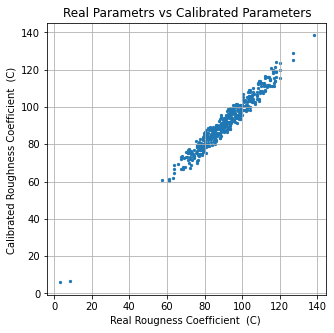

In [226]:
ax=plt.figure(1)
ax.set_figwidth(5)
ax.set_figheight(5)

plt.scatter(np.array(C_n)[0][1:],np.array(Solu.iloc[:429]),marker="o",s=5)
plt.grid()
plt.title("Real Parametrs vs Calibrated Parameters")
plt.xlabel("Real Rougness Coefficient  (C) ")
plt.ylabel("Calibrated Roughness Coefficient  (C) ")
#plt.savefig('Roughness_C.png', dpi=300,bbox_inches='tight')

In [241]:
def result1(solution):
    
    sol_pat = solution[429:549]
    sol_pat 

    pat3 = pd.DataFrame(np.reshape(sol_pat,(24,5)))
    pat3

    pat_list=np.zeros((334,24))
    for i in range(334):
        if pat_1.iloc[i,1] == "DMA1_pat":
            pat_list[i]= pat3.iloc[:,0]
        
        elif pat_1.iloc[i,1] == "DMA2_pat":
            pat_list[i]= pat3.iloc[:,1]
        
        elif pat_1.iloc[i,1] == "DMA3_pat":
            pat_list[i]= pat3.iloc[:,2]
        
        elif pat_1.iloc[i,1] == "DMA4_pat":
            pat_list[i]= pat3.iloc[:,3]
    
        else:
            pat_list[i]= pat3.iloc[:,4]

    for i in range(334):
        junction = wn.get_node(pat_n.iloc[i][1])
        junction.demand_timeseries_list[0].pattern_name=A[i]
        #print(junction.demand_timeseries_list[0].pattern_name)
    
    for i in range(334):
        wn.add_pattern(f"{i}",pat_list[0,:])
    wn.pattern_name_list
    #loop 
    #sensor_no = [22, 26, 28, 38, 55, 58, 65, 70, 75, 79, 92, 102, 109, 114, 119, 128, 147, 148, 153, 164, 190, 195, 205, 206, 210, 211, 244, 252, 286, 303, 306, 313, 317, 327, 332, 339, 359, 372, 389, 390, 391, 392, 393, 394, 395]
    boost_node = ['R1','J301','J287','J238','J178','J142','J131']
    for i in range(7):
        wn.add_pattern(f'SourcePattern_{i}', np.array(doss)[i])
        wn.add_source(f'{boost_node[i]}',boost_node[i],'SETPOINT', 4*10**(-3), f'SourcePattern_{i}')
        
    for i in range(len(tanks)):
        junction = wn.get_node(tanks[i])
        junction.init_level = tank_1[i]
        #print(junction.init_level)
    
#     for i in range(334):
#         wn.add_pattern(f"{i}",[solution[i+429]])

#     for i in range(334):
#         junction = wn.get_node(pat_n.iloc[i][1])
#         junction.demand_timeseries_list[0].pattern_name=A[i]
#         #print(junction.demand_timeseries_list[0].pattern_name)
    
    for i in range(len(A2)):
        junction1 = wn.get_link(A2[i])
        junction1.roughness=solution[i]
        junction1.bulk_coeff = -0.5/(3600*24)
        junction1.wall_coeff = (-1*sol[429])/(coeff[1][i]*3600*24)
        
        # Modify the water network model
    wn.options.time.duration = 3600*24
    wn.options.time.quality_timestep =3600
    wn.options.time.hydraulic_timestep =3600
    wn.options.time.pattern_timestep = 3600
    wn.options.time.report_timestep =3600
    wn.options.quality.parameter = 'CHEMICAL'
    wn.options.reaction.bulk_order = 1
    wn.options.reaction.tank_order = 1
    wn.options.reaction.wall_order = 1
    wn.options.hydraulic.required_pressure = 15
    wn.options.hydraulic.minimum_pressure = 0
    
    sim = wntr.sim.EpanetSimulator(wn)
    wn.reset_initial_values()
    results = sim.run_sim()
    #print(results)
    df1=pd.DataFrame(results.node['pressure'])
    df2=pd.DataFrame(results.node['quality'])
    df3 = pd.DataFrame(results.node['demand'])
    kpk1=pd.DataFrame(np.array(df1))
    kpk2=pd.DataFrame(np.array(df2))
    kpk3=pd.DataFrame(np.array(df3))
    kp1 = kpk1.filter(sensor_no)
    kp2 = kpk2.filter(sensor_no)
    kp3 = kpk3.filter(sensor_no)
    # # dfk = np.array(dfk)
    # kpk1 = kpk[1]
    #for i in range(334):
        #wn.remove_pattern(f"{i}")
    sumk1 = np.mean(np.square((np.array(kp1).flatten())-(np.array(K_pm).flatten()))) 
    + np.mean(np.square((np.array(kp3).flatten())-(np.array(K_fm).flatten())))   
    + np.mean(np.square((np.array(kp2).flatten())-(np.array(K_qm).flatten())))      #/P_m1))
       
    for i in range(334):
        wn.remove_pattern(f"{i}")

    for i in range(7):
        wn.remove_source(f'{boost_node[i]}')   
        
    for i in range(7):
        wn.remove_pattern(f"SourcePattern_{i}")
    sumk1
    
    return kp1,kp2,kp3

In [244]:
KP1,KP2,KP3 = result1(np.array(Solu.iloc[:,0]))

Text(0, 0.5, 'Calibrated P ')

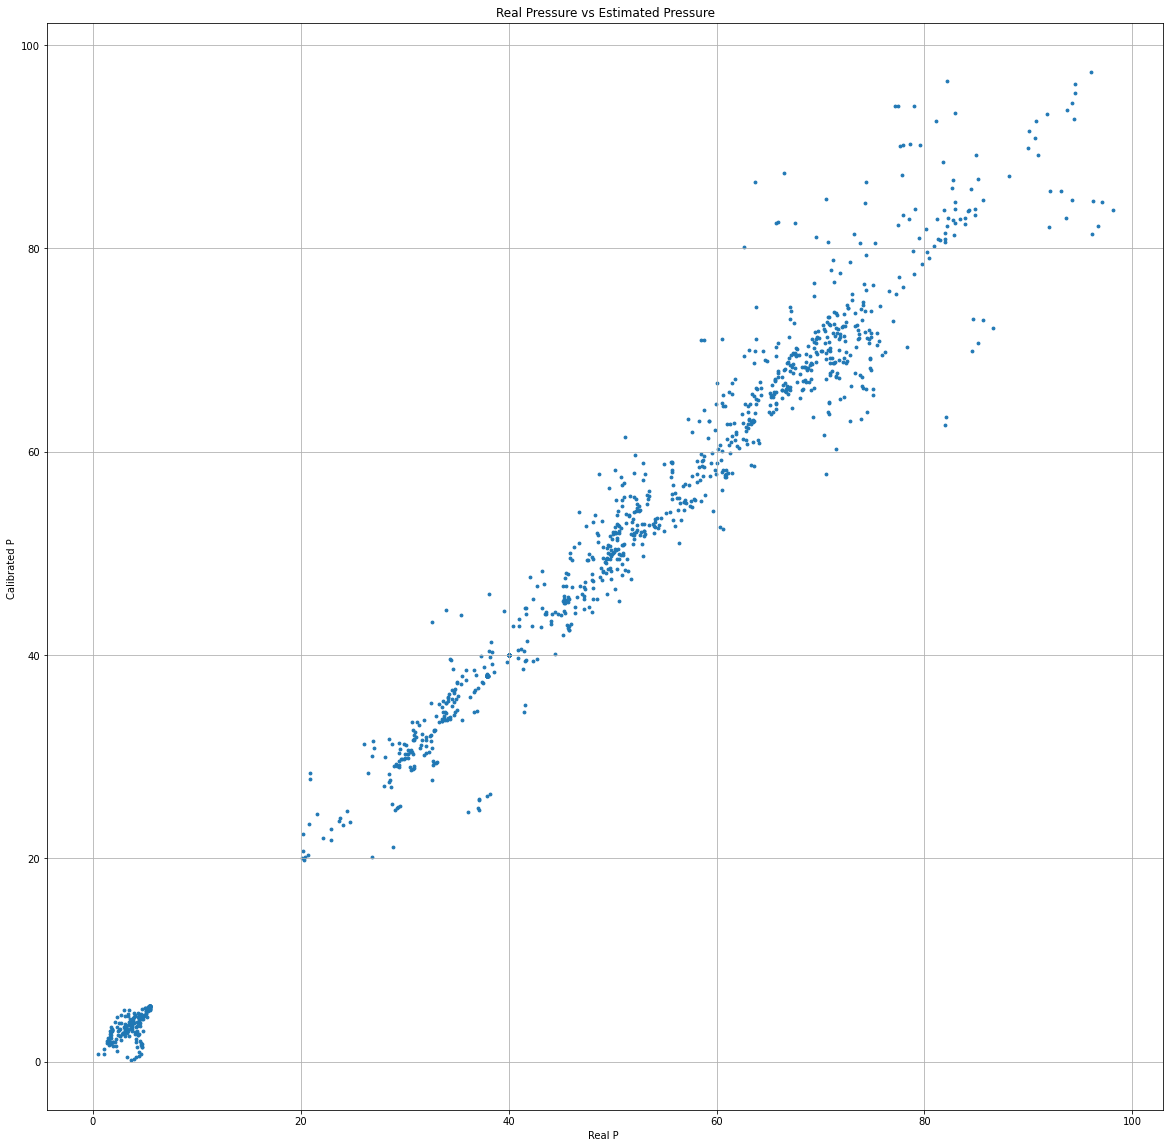

In [250]:
ax=plt.figure(1)
ax.set_figwidth(20)
ax.set_figheight(20)

plt.scatter(K_pm,KP1,marker="o",s=8)
plt.grid()
plt.title("Real Pressure vs Estimated Pressure")
plt.xlabel("Real P ")
plt.ylabel("Calibrated P ")
#plt.savefig('Roughness_C.png', dpi=300,bbox_inches='tight')

Text(0, 0.5, 'Calibrated Q ')

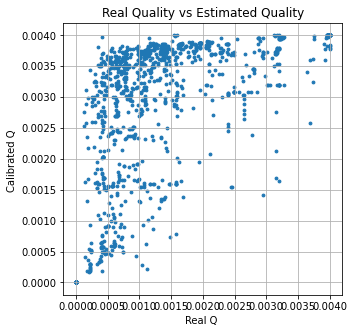

In [256]:
ax=plt.figure(1)
ax.set_figwidth(5)
ax.set_figheight(5)

plt.scatter(K_qm,KP2,marker="o",s=8)
plt.grid()
plt.title("Real Quality vs Estimated Quality")
plt.xlabel("Real Q ")
plt.ylabel("Calibrated Q ")

Text(0, 0.5, 'Calibrated F ')

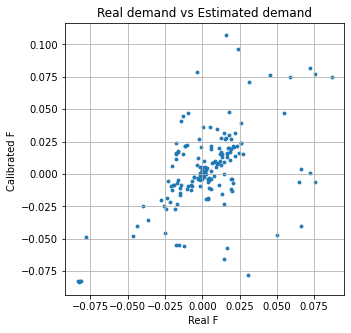

In [255]:
ax=plt.figure(1)
ax.set_figwidth(5)
ax.set_figheight(5)

plt.scatter(K_fm,KP3,marker="o",s=8)
plt.grid()
plt.title("Real demand vs Estimated demand")
plt.xlabel("Real F ")
plt.ylabel("Calibrated F ")

In [ ]:
 for i in range(334):
        wn.remove_pattern(f"{i}")

In [ ]:
def OF_check(solution):
    #loop 
    #sensor_no = [22, 26, 28, 38, 55, 58, 65, 70, 75, 79, 92, 102, 109, 114, 119, 128, 147, 148, 153, 164, 190, 195, 205, 206, 210, 211, 244, 252, 286, 303, 306, 313, 317, 327, 332, 339, 359, 372, 389, 390, 391, 392, 393, 394, 395]
    for i in range(len(tanks)):
        junction = wn.get_node(tanks[i])
        junction.init_level = tank_1[i]
        #print(junction.init_level)
    
    for i in range(334):
        wn.add_pattern(f"{i}",[solution[i+429]])

    for i in range(334):
        junction = wn.get_node(pat_n.iloc[i][1])
        junction.demand_timeseries_list[0].pattern_name=A[i]
        #print(junction.demand_timeseries_list[0].pattern_name)
    
    for j in range(len(solution)-334):
        for i in range(len(A2)):
            junction1 = wn.get_link(A2[i])
        junction1.roughness=solution[j]
        #print(junction1.roughness)
        
        # Modify the water network model
    wn.options.time.duration = 3600
    wn.options.time.quality_timestep =3600
    wn.options.time.hydraulic_timestep =3600
    wn.options.time.pattern_timestep = 3600
    wn.options.time.report_timestep =3600
    wn.options.quality.parameter = 'CHEMICAL'
    wn.options.reaction.bulk_order = 1
    wn.options.reaction.tank_order = 1
    wn.options.reaction.wall_order = 1
    wn.options.hydraulic.required_pressure = 1
    wn.options.hydraulic.minimum_pressure = 0
        
        # Simulate hydraulics
    sim = wntr.sim.EpanetSimulator(wn)
    #wn.reset_initial_values()
    results = sim.run_sim()
    #print(results)
    df1=pd.DataFrame(results.node['pressure'])
    df2=pd.DataFrame(results.link['flowrate'])
    #zero_flow = ['PU3','PU5','PU6','PU9','PU11','P446']
    #df2.drop(zero_flow,inplace=True)
    K_p=pd.concat([df1,df2],axis=1)
    K_p = K_p.filter(sensor)
    K_pk=np.array(K_p)
    K_pk1 = K_pk[1]
    for i in range(334):
        wn.remove_pattern(f"{i}")
    sumk1 = np.sum(np.square((kpk1-K_pk1)/K_pm))                #/P_m1))
    sumk1    
    
    return df1,df2

In [ ]:
D1,D2 = OF_check(result.x)

In [ ]:
D1

In [ ]:
D2

In [ ]:
K_p22=pd.concat([D1,D2],axis=1)
K_p22 = K_p22.filter(sensor)
K_p22

In [ ]:
ax=plt.figure(1)
ax.set_figwidth(10)
ax.set_figheight(10)
plt.scatter(K_pm,K_p22.iloc[1,:])
#plt.plot()
#plt.plot(Mdf,color='k')
plt.xlabel("Nodes & Links")
plt.ylabel("Pressure (m) & Flowrate (kg/m3)")
#plt.ylim(0,0.001)
#plt.legend()


In [ ]:
ax=plt.figure(1)
ax.set_figwidth(100)
ax.set_figheight(5)
plt.plot(D2.iloc[1,:])
plt.plot(df2.iloc[1,:])
#plt.plot(Mdf,color='k')
plt.xlabel("Time (s)")
plt.ylabel("Conc (kg/m3)")
#plt.ylim(0,0.001)
#plt.legend()


In [ ]:
def check(solution):
    #loop 
    sensor_no = [22, 26, 28, 38, 55, 58, 65, 70, 75, 79, 92, 102, 109, 114, 119, 128, 147, 148, 153, 164, 190, 195, 205, 206, 210, 211, 244, 252, 286, 303, 306, 313, 317, 327, 332, 339, 359, 372, 389, 390, 391, 392, 393, 394, 395]
    for i in range(334):
        wn.add_pattern(f"{i}",[solution[i+429]])

    for i in range(334):
        junction = wn.get_node(pat_n.iloc[i][1])
        junction.demand_timeseries_list[0].pattern_name=A[i]
        #print(junction.demand_timeseries_list[0].pattern_name)
    
    for j in range(len(solution)-334):
        for i in range(len(A2)):
            junction1 = wn.get_link(A2[i])
        junction1.roughness=solution[j]
        #print(junction1.roughness)
        
        # Modify the water network model
    wn.options.time.duration = 3600
    wn.options.time.quality_timestep =3600
    wn.options.time.hydraulic_timestep =3600
    wn.options.time.pattern_timestep = 3600
    wn.options.time.report_timestep =3600
    wn.options.quality.parameter = 'CHEMICAL'
    wn.options.reaction.bulk_order = 1
    wn.options.reaction.tank_order = 1
    wn.options.reaction.wall_order = 1
    wn.options.hydraulic.required_pressure = 1
    wn.options.hydraulic.minimum_pressure = 0
        
        # Simulate hydraulics
    sim = wntr.sim.EpanetSimulator(wn)
    #wn.reset_initial_values()
    results = sim.run_sim()
    #print(results)
    df=pd.DataFrame(results.node['head'])
    df1 = np.array(df)
    #df2 = pd.DataFrame(df1)
    #dfk = df2.filter(sensor_no, axis=1)
    dfk1 = df1[1]
    for i in range(334):
        wn.remove_pattern(f"{i}")
    sumk1 = np.sum(np.square((kpk1-dfk1)/P_m1))
    sumk1    
    
    return df1

In [ ]:
A = ['0','1','2','3','4','5','6','7','8',
 '9','10','11',
 '12',
 '13',
 '14','15',
 '16','17',
 '18','19',
 '20',
 '21',
 '22',
 '23',
 '24',
 '25',
 '26',
 '27',
 '28',
 '29',
 '30',
 '31',
 '32',
 '33',
 '34',
 '35',
 '36',
 '37',
 '38',
 '39',
 '40',
 '41',
 '42',
 '43',
 '44',
 '45',
 '46',
 '47',
 '48',
 '49',
 '50',
 '51',
 '52',
 '53',
 '54',
 '55',
 '56',
 '57',
 '58',
 '59',
 '60',
 '61',
 '62',
 '63',
 '64',
 '65',
 '66',
 '67',
 '68',
 '69',
 '70',
 '71',
 '72',
 '73',
 '74',
 '75',
 '76',
 '77',
 '78',
 '79',
 '80',
 '81',
 '82',
 '83',
 '84',
 '85',
 '86',
 '87',
 '88',
 '89',
 '90',
 '91',
 '92',
 '93',
 '94',
 '95',
 '96',
 '97',
 '98',
 '99',
 '100',
 '101',
 '102',
 '103',
 '104',
 '105',
 '106',
 '107',
 '108',
 '109',
 '110',
 '111',
 '112',
 '113',
 '114',
 '115',
 '116',
 '117',
 '118',
 '119',
 '120',
 '121',
 '122',
 '123',
 '124',
 '125',
 '126',
 '127',
 '128',
 '129',
 '130',
 '131',
 '132',
 '133',
 '134',
 '135',
 '136',
 '137',
 '138',
 '139',
 '140',
 '141',
 '142',
 '143',
 '144',
 '145',
 '146',
 '147',
 '148',
 '149',
 '150',
 '151',
 '152',
 '153',
 '154',
 '155',
 '156',
 '157',
 '158',
 '159',
 '160',
 '161',
 '162',
 '163',
 '164',
 '165',
 '166',
 '167',
 '168',
 '169',
 '170',
 '171',
 '172',
 '173',
 '174',
 '175',
 '176',
 '177',
 '178',
 '179',
 '180',
 '181',
 '182',
 '183',
 '184',
 '185',
 '186',
 '187',
 '188',
 '189',
 '190',
 '191',
 '192',
 '193',
 '194',
 '195',
 '196',
 '197',
 '198',
 '199',
 '200',
 '201',
 '202',
 '203',
 '204',
 '205',
 '206',
 '207',
 '208',
 '209',
 '210',
 '211',
 '212',
 '213',
 '214',
 '215',
 '216',
 '217',
 '218',
 '219',
 '220',
 '221',
 '222',
 '223',
 '224',
 '225',
 '226',
 '227',
 '228',
 '229',
 '230',
 '231',
 '232',
 '233',
 '234',
 '235',
 '236',
 '237',
 '238',
 '239',
 '240',
 '241',
 '242',
 '243',
 '244',
 '245',
 '246',
 '247',
 '248',
 '249',
 '250',
 '251',
 '252',
 '253',
 '254',
 '255',
 '256',
 '257',
 '258',
 '259',
 '260',
 '261',
 '262',
 '263',
 '264',
 '265',
 '266',
 '267',
 '268',
 '269',
 '270',
 '271',
 '272',
 '273',
 '274',
 '275',
 '276',
 '277',
 '278',
 '279',
 '280',
 '281',
 '282',
 '283',
 '284',
 '285',
 '286',
 '287',
 '288',
 '289',
 '290',
 '291',
 '292',
 '293',
 '294',
 '295',
 '296',
 '297',
 '298',
 '299',
 '300',
 '301',
 '302',
 '303',
 '304',
 '305',
 '306',
 '307',
 '308',
 '309',
 '310',
 '311',
 '312',
 '313',
 '314',
 '315',
 '316',
 '317',
 '318',
 '319',
 '320',
 '321',
 '322',
 '323',
 '324',
 '325',
 '326',
 '327',
 '328',
 '329',
 '330',
 '331',
 '332',
 '333']

In [ ]:
pre_sim = check(result.x)

In [ ]:
np.set_printoptions(suppress=True)
pre_sim

In [ ]:
np.set_printoptions(suppress=True)
P_m1

In [ ]:
#89.7674951	83.42123319	82.28255253	83.37433371	82.62774656	83.50848089	84.78401914	81.19787163	77.7556742	0	36.54123727


In [ ]:
np.shape(pre_sim)

In [ ]:
A = np.array([91.267, 84.556, 82.319, 83.397, 82.771, 83.459, 84.829, 81.272, 77.624,  0.   , 36.576])

In [ ]:
#([89.767, 83.421, 82.283, 83.374, 82.628, 83.508, 84.784, 81.198, 77.756,  0.   , 36.541])

In [ ]:
P_m1-pre_sim

In [ ]:
np.sum(P_m1-pre_sim)

In [ ]:
#0	1.216582355	1.171850395	1.179924098	1.269814018	1.161229137	1.239236085	1.191264475	1.236951437	1.290636688


In [ ]:
'''89
105
109
111
95
87
98
102
94
110
94
89'''
